## **Analyzing Terrorist Incidents in Somalia**

### Introduction

Somalia has grappled with terrorism amid ongoing political instability and the rise of extremist groups, leading to significant casualties and societal disruption. While media narratives often spotlight high-profile suicide bombings, a detailed analysis reveals that non-suicide attacks constitute a larger share of fatalities.

This project aims to dissect the patterns of terrorism in Somalia, focusing on attack methods, casualty trends, and weapon types. By uncovering correlations and trends, the study will illuminate the most critical threats and inform effective security strategies.

Ultimately, this analysis serves as a resource for policymakers and security forces, offering targeted recommendations to enhance counter-terrorism efforts and foster a more secure Somalia.

### Background

Somalia has faced decades of conflict and terrorism, fueled by political instability and the influence of extremist groups. This environment has led to a variety of violent incidents, including bombings, armed assaults, and assassinations, posing significant threats to public safety.

Data shows that while suicide bombings account for 27% of casualties, other methods, particularly armed assaults and bombings, contribute to 73% of fatalities. This underscores the need for a deeper understanding of terrorism dynamics in the region.

The analysis also reveals that armed assaults are primarily linked to firearms, whereas bombings predominantly involve explosives. The geographical distribution of violence highlights regions like Banaadir, Shabeellaha Hoose, and Bay as key areas of concern, while other regions experience lower casualty rates.

This project aims to analyze the nature of terrorism in Somalia, focusing on attack methods, casualty patterns, weapon types, and targeted locations, ultimately providing actionable recommendations for enhancing security measures and counter-terrorism strategies tailored to the country's unique challenges.

### Objective

This project aims to analyze terrorism in Somalia by:

1. **Identifying trends** in attack methods and associated casualties.
2. **Examining correlations** between attack types and weapon usage.
3. **Assessing regional impacts**, focusing on areas with high violence.
4. **Evaluating changes** in terrorism tactics over time.
5. **Providing actionable recommendations** for enhancing security measures.

The goal is to deliver insights that will aid policymakers and security forces in effectively combating terrorism.

### Problem Statement

Somalia faces a persistent terrorism threat marked by various attack methods, with significant casualties stemming from both suicide and non-suicide attacks. While media attention often highlights high-profile suicide bombings, data reveal that non-suicide methods—such as armed assaults and assassinations—account for a substantial portion of fatalities. This discrepancy can hinder effective counter-terrorism strategies.

Additionally, the correlation between specific attack types and weapon usage remains underexplored, limiting security forces' ability to anticipate threats. The uneven regional distribution of attacks further complicates the understanding of violence, resulting in inadequate security measures.

Addressing these issues is critical for developing a comprehensive counter-terrorism strategy in Somalia. This project aims to analyze the complexities of terrorism in the region to provide actionable recommendations for enhancing security and reducing casualties.

In [200]:
# Libraries for data manipulation, cleaning, and basic analysis
import pandas as pd
import numpy as np

# For static visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
from PIL import Image

# For generating word clouds
from wordcloud import WordCloud
from folium.plugins import HeatMap
from IPython.display import display

# For handling geospatial data
import geopandas as gpd  # For geospatial data operations
from shapely.geometry import Point  # For creating geometry objects for maps
import folium  # For creating interactive maps
from folium.plugins import HeatMap  # Heatmap for density plotting on maps
from folium.plugins import MarkerCluster

# To suppress warnings that may clutter the output
import warnings
warnings.filterwarnings("ignore")

## **Read the Data**

In [201]:
data = pd.read_csv("GTD dataset.csv", encoding='ISO-8859-1')

In [202]:
df = data.copy()

In [203]:
df.head()

,eventid,iyear,imonth,iday,extended,provstate,city,latitude,longitude,location,...,weapdetail,nkill,nwound,nkillter,nwoundte,property,propextent,propextent_txt,propvalue,propcomment
0,2.020000e+11,2016,11,26,0,Banaadir,Mogadishu,2.059818,45.326114,The incident occurred in the Afesyoni area of ...,...,A remote-controlled explosives-laden vehicle w...,30.0,43.0,0.0,0.0,1,4.0,Unknown,-99.0,A market and nearby buildings were damaged in ...
1,2.010000e+11,2008,10,17,0,Banaadir,Mogadishu,2.059819,45.326115,The incidents occurred at the International Ai...,...,Mortars,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN
2,2.010000e+11,2014,7,15,0,Banaadir,Mogadishu,2.059818,45.326114,The incident occurred in the Wadajir neighborh...,...,An explosives laden vehicle was used in the at...,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN
3,2.010000e+11,2007,1,24,0,Banaadir,Mogadishu,2.059819,45.326115,The incident occurred at Mogadishu Internation...,...,NaN,2.0,0.0,0.0,0.0,-9,NaN,NaN,NaN,NaN
4,2.010000e+11,2007,2,10,0,Banaadir,Mogadishu,2.059819,45.326115,The incident occurred near the Mogadishu airport.,...,NaN,1.0,3.0,0.0,0.0,0,NaN,NaN,NaN,NaN


## **Data Cleaning**

### **Understand the Data**

In [204]:
print(f"""   
- The dataset covers {df.provstate.nunique():,} regions and {df.city.nunique():,} cities across Somalia.
- It includes data on terrorist attacks from {df.iyear.nunique()} years, ranging from {df.iyear.min()} to {df.iyear.max()}.
- Overall, {df.index.nunique():,} terrorist attacks are recorded.
- This results in approximately {int(df['nkill'].sum()) + int(df['nwound'].sum()):,} casualties. 
- Which include {int(df.nkill.sum()):,} deaths and {int(df.nwound.sum()):,} injuries.
""")

   
- The dataset covers 19 regions and 606 cities across Somalia.
- It includes data on terrorist attacks from 38 years, ranging from 1975 to 2020.
- Overall, 5,315 terrorist attacks are recorded.
- This results in approximately 24,390 casualties. 
- Which include 13,168 deaths and 11,222 injuries.



#### **Renaming the columns**

In [205]:
# Clean columns by renaming them
df.rename(columns={
    'iyear': 'year', 'imonth': 'month', 'iday': 'day', 'success': 'success', 'suicide': 'suicide',
    'provstate': 'region', 'city': 'city', 'latitude': 'lat', 'longitude': 'long', 'summary': 'summary',
    'attacktype1_txt': 'attack_type', 'targtype1_txt': 'target_type', 'targsubtype1_txt': 'target_subtype', 
    'new_target': 'target',  'natlty1_txt': 'nationality', 'gname': 'group_name', 'claimmode_txt': 'claim_mode',
    'weaptype1_txt': 'weapon_type', 'weapsubtype1_txt': 'weapon_subtype', 'weapdetail' : 'weapon_detail',
    'nkill': 'killed', 'nwound': 'wounded', 'nkillter': 'terr_killed', 'nwoundte': 'terr_wounded',
    'target1': 'target1', 'propextent_txt': 'propextent', 'extended': 'extended'
}, inplace=True)

In [206]:
# Reorganize columns
new_column_order = [
    'eventid','year', 'month', 'day', 'region', 'city', 'location','lat', 'long', 'attack_type', 'suicide', 'success',
    'weapon_type', 'weapon_subtype', 'weapon_detail', 'target_type', 'target_subtype', 'target', 
    'killed', 'wounded', 'nationality', 'group_name', 'terr_killed', 'terr_wounded', 'claim_mode', 
    'propextent', 'summary', 'motive', 'extended'
]
# Reassign columns in the new order
df = df[new_column_order]

In [207]:
# Dictionary to rename and merge terrorist group names
group_rename_dict = {
    'Front for the Liberation of the French Somali Coast': 'FSCLF',
    'Somali Salvation Front (SSF)': 'SSF',
    'Somali Salvation Democratic Front (SSDF)': 'SSDF',
    'Somali National Movement': 'SNM',
    'United Somali Congress': 'USC',
    'Somali Patriotic Movement': 'SPM',
    'Somali National Alliance': 'SNA',

    'Aidid Militia': 'Aideed Militia',
    'Gunmen loyal to Mohammad Farah Aideed': 'Aideed Militia',
    'Supporters of Ali Mahdi Mohammed': 'Ali Mahdi Supporters',
    'Somali Guerrillas': 'Somali Guerrillas',
    'U/I Somali Militiamen': 'Somali Militiamen',
    'Mousa Ismail sub-clan': 'Clan Militias',
    'Habr Gedir Clan': 'Clan Militias',
    'Rahanwein Resistance Army (RRA)': 'Clan Militias',
    'Majerten clansmen': 'Clan Militias',
    'Rival clan': 'Clan Militias',
    'Sa\'ad Militia': 'Clan Militias',
    'Matan Abdulle': 'Clan Militias',
    'Marhan Clan': 'Clan Militias',
    'Tribesmen': 'Clan Militias',
    'Awdal Regional Administration Army (ARAA)': 'Clan Militias',
    

    'Islamist extremists': 'Other Terrorist Groups',
    'Muslim Fundamentalists': 'Other Terrorist Groups',
    'Islamic Tendency': 'Other Terrorist Groups',
    'Muslim extremists': 'Other Terrorist Groups',
    'Somali Islamic Front': 'Other Terrorist Groups',
    'Sunni Muslim extremists': 'Other Terrorist Groups',
    'Islamic Party (Somalia)': 'Other Terrorist Groups',
    'Raskamboni Movement': 'Other Terrorist Groups',

    'Hizbul al Islam (Somalia)': 'Al Shabaab',
    'Al-Shabaab': 'Al Shabaab',
    'Al-Qaida': 'Al Shabaab',

    'Islamic State of Iraq and the Levant (ISIL)': 'Daacish',
    'Jabha East Africa': 'Daacish',

    'Ahlu-sunah Wal-jamea (Somalia)': 'ASWJ',

    'Militia Members': 'Militia',
    'Shabelle Valley militia': 'Militia',
    'Supporters of Muhammad Umar Habib': 'Mohamed Dheere Militia',
    'Supporters of Muse Sudi Yalahow': 'Muse Sudi Militia',
    'Musa Sudi Yalahow Militia': 'Muse Sudi Militia',
    'Gunmen': 'Militia',
    'Ogaden National Liberation Front (ONLF)': 'ONLF',
}

# Apply the renaming
df['group_name'] = df['group_name'].replace(group_rename_dict)


In [208]:
df.head()

,eventid,year,month,day,region,city,location,lat,long,attack_type,...,nationality,group_name,terr_killed,terr_wounded,claim_mode,propextent,propextent,summary,motive,extended
0,2.020000e+11,2016,11,26,Banaadir,Mogadishu,The incident occurred in the Afesyoni area of ...,2.059818,45.326114,Assassination,...,Somalia,Al Shabaab,0.0,0.0,Personal claim,4.0,Unknown,11/26/2016: An explosives-laden vehicle detona...,NaN,0
1,2.010000e+11,2008,10,17,Banaadir,Mogadishu,The incidents occurred at the International Ai...,2.059819,45.326115,Bombing/Explosion,...,Somalia,Unknown,0.0,0.0,NaN,NaN,NaN,"10/17/2008: On Friday afternoon at about 1500,...",The specific motive for the attack is unknown.,0
2,2.010000e+11,2014,7,15,Banaadir,Mogadishu,The incident occurred in the Wadajir neighborh...,2.059818,45.326114,Bombing/Explosion,...,Somalia,Unknown,0.0,0.0,NaN,NaN,NaN,"07/15/2014: An explosives-laden vehicle, inten...",NaN,0
3,2.010000e+11,2007,1,24,Banaadir,Mogadishu,The incident occurred at Mogadishu Internation...,2.059819,45.326115,Bombing/Explosion,...,Somalia,Unknown,0.0,0.0,NaN,NaN,NaN,01/24/2007: At least two people were killed in...,To attack Somalian infrastructure.,0
4,2.010000e+11,2007,2,10,Banaadir,Mogadishu,The incident occurred near the Mogadishu airport.,2.059819,45.326115,Bombing/Explosion,...,Somalia,Unknown,0.0,0.0,NaN,NaN,NaN,2/10/2007: Several missiles were fired near th...,Unknown,0


#### **Handling Missing Values**

In [209]:
# Check for duplicate columns
duplicate_columns = df.columns[df.columns.duplicated()]
# If duplicates are found, drop or rename them (based on your needs)
df = df.loc[:, ~df.columns.duplicated()]
# Check for duplicate indices
duplicate_indices = df.index[df.index.duplicated()]
# If duplicates are found, reset the index or make it unique
df = df.reset_index(drop=True)  # If the index isn't meaningful

In [210]:
# checking the null value with percentage of null values

def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

missing_values= missing_values_table(df)
missing_values.style.background_gradient(cmap='Greens')

Your selected dataframe has 29 columns.
There are 17 columns that have missing values.


,Missing Values,% of Total Values
motive,4021,75.700000
propextent,3553,66.800000
claim_mode,3541,66.600000
weapon_detail,3010,56.600000
location,2952,55.500000
wounded,1329,25.000000
terr_wounded,953,17.900000
killed,927,17.400000
terr_killed,773,14.500000
weapon_subtype,763,14.400000


In [211]:
df['motive'].fillna(value='Ambiguous', inplace=True) #I did not want to miss any value. So I replaced them with a value that has the same type.
df['summary'].fillna(value='Not Recorded', inplace=True)
df['city'].fillna(value='Unknown', inplace=True)
df['target'].fillna(value='Unknown', inplace=True)
df["killed"].fillna(df["killed"].median(), inplace=True)
df["terr_killed"].fillna(df["terr_killed"].median(), inplace=True)
df["terr_wounded"].fillna(df["terr_wounded"].median(), inplace=True)
df["wounded"].fillna(df["wounded"].median(), inplace=True)
df["lat"].fillna(df["lat"].mean(), inplace=True)
df["long"].fillna(df["long"].mean(), inplace=True)

In [212]:
# Define weapon-related keywords
weapon_keywords = {
    'gun': ['gun', 'rifle', 'pistol', 'firearm', 'handgun', 'machine gun'],
    'explosive': ['explosive', 'bomb', 'grenade', 'IED', 'landmine'],
    'knife': ['knife', 'blade', 'sharp object'],
    'other': ['chemical weapon', 'biological weapon', 'poison'],
}

# Function to extract weapon information
def extract_weapon_info(summary):
    # Convert summary to string and lower case
    text = str(summary).lower() if pd.notna(summary) else ''
    
    # Check for each weapon type in the summary
    for weapon_type, keywords in weapon_keywords.items():
        if any(keyword in text for keyword in keywords):
            return weapon_type.capitalize()  # Return the weapon type if found
    
    return 'No weapon specified'  # Default if no keywords are found

# Apply the function to the summary column
df['weapon_detail'] = df['summary'].apply(extract_weapon_info)


#### **Duplicate Records**

In [213]:
df.duplicated().sum()
duplicates=df[df.duplicated(keep=False)]
df = df.drop_duplicates(keep='first')
df.shape

(5292, 29)

In [214]:
# Replace invalid month or day (like 0) with a default value (e.g., 1)
df['month'] = df['month'].replace(0, 1)
df['day'] = df['day'].replace(0, 1)

# Combine year, month, and day into a single 'date' column
df['date'] = pd.to_datetime(df[['year', 'month', 'day']], errors='coerce')

# Create 'Day_of_week' column (e.g., Monday, Tuesday, etc.)
df['day_of_week'] = df['date'].dt.day_name()

# Extract the month name (abbreviated)
df['month_name'] = df['date'].dt.strftime('%b')

df['total_casualties'] = df['killed'] + df['wounded']

In [215]:
def numeric_and_qualitative_cols(df):
    # selects numeric columns
    df_numeric=df.select_dtypes(include=[np.number])
    numeric_cols=df_numeric.columns.values

    # selects non numeric columns
    df_non_numeric = df.select_dtypes(exclude=[np.number])
    non_numeric_cols = df_non_numeric.columns.values

    return numeric_cols, non_numeric_cols

##  1. **Data Overview**
   - How many total events are recorded in the dataset?
   - What unique attack types and terrorist groups are present?
   - What percentage of events have missing values in critical fields?
   - How many unique cities and regions are included?
   - What is the distribution of events across different years?

In [216]:
# Filter out rows where the region is 'Unknown'
df_filtered = df[df['region'] != 'Unknown']

# Print the summary information
print(f"""   
- The dataset covers {df_filtered.region.nunique():,} regions and {df_filtered.city.nunique():,} cities across Somalia.
- It includes data on terrorist attacks from {df_filtered.year.nunique()} years, ranging from {df_filtered.year.min()} to {df_filtered.year.max()}.
- Overall, {df_filtered.index.nunique():,} terrorist attacks are recorded.
- This results in approximately {int(df_filtered['killed'].sum()) + int(df_filtered['wounded'].sum()):,} casualties. 
- Which include {int(df_filtered.killed.sum()):,} deaths and {int(df_filtered.wounded.sum()):,} injuries.
""")

   
- The dataset covers 18 regions and 603 cities across Somalia.
- It includes data on terrorist attacks from 38 years, ranging from 1975 to 2020.
- Overall, 5,270 terrorist attacks are recorded.
- This results in approximately 25,161 casualties. 
- Which include 13,960 deaths and 11,201 injuries.



## **1. Temporal Analysis**

- ### **What are the yearly trends in attacks?**  

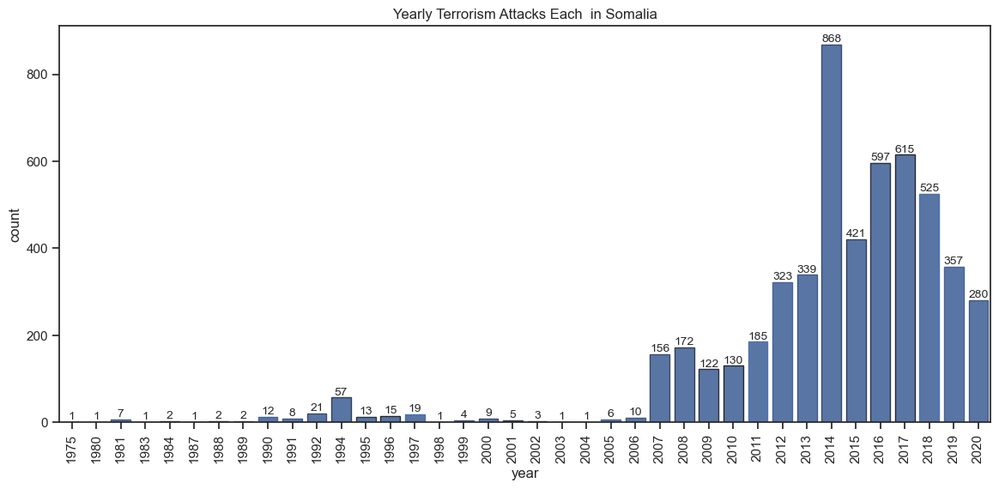

In [308]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Count occurrences for each year
year_counts = df['year'].value_counts().sort_index()

# Create a figure for the countplot
plt.subplots(figsize=(14, 6))

# Create the countplot using the balanced color palette
ax = sns.countplot(data=df, x='year', edgecolor=sns.color_palette(palette, 7))

# Rotate x-ticks for better readability
plt.xticks(rotation=90)

# Set the title of the plot
plt.title('Yearly Terrorism Attacks Each  in Somalia')

# Add the number of incidents on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),  # Positioning the label
                ha='center', va='bottom', fontsize=10)

# Show the plot
plt.show()

- ### **Which years experienced significant spikes or declines in attacks?**  

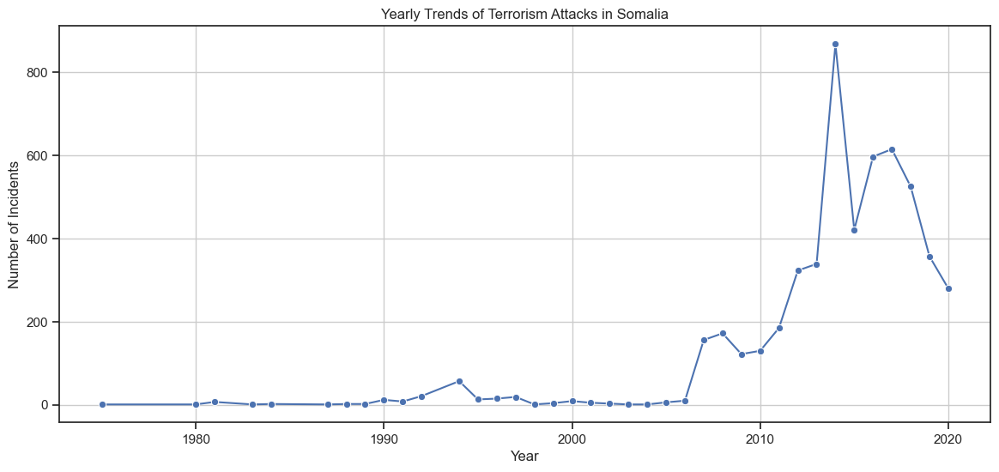

In [218]:
# Group by year and count incidents
annual_counts = df.groupby('year').size()

# Set the Seaborn theme to 'ticks'
sns.set_theme(style='ticks')

# Create the line plot
plt.figure(figsize=(14, 6))
sns.lineplot(x=annual_counts.index, y=annual_counts.values, 
             marker="o", color=sns.color_palette("dark:b_r")[0])  # Use the first color from the palette

# Adding title and labels
plt.title("Yearly Trends of Terrorism Attacks in Somalia")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.grid(True)

# Show the plot
plt.show()

- ### **Which months see the highest terrorism attacks?**  

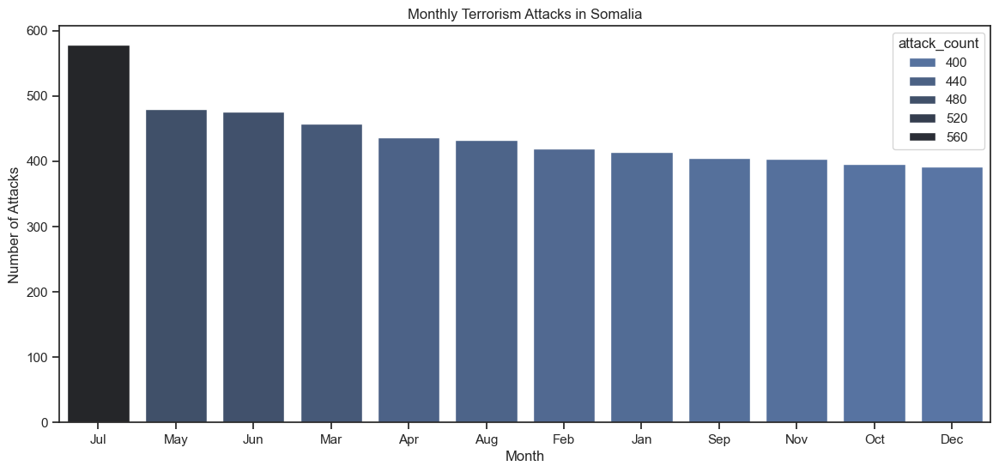

In [295]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# 2. Attack count by month (Bar Chart)
attacks_per_month = df.groupby('month_name').size().reset_index(name='attack_count')
attacks_per_month = attacks_per_month.sort_values(by='attack_count', ascending=False)
plt.figure(figsize=(14, 6))
sns.barplot(x='month_name', y='attack_count', hue='attack_count', data=attacks_per_month, palette=palette)
plt.title('Monthly Terrorism Attacks in Somalia')
plt.xlabel('Month')
plt.ylabel('Number of Attacks')
plt.show()


- ### **Are certain days of the month associated with higher attack frequencies?**  

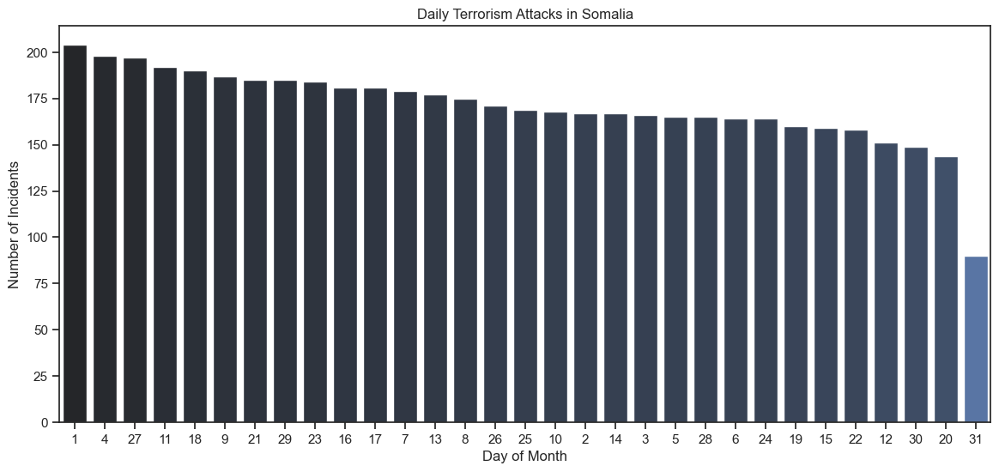

In [297]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = 'dark:b_r'

# Create a new DataFrame with counts of incidents for each day
day_counts = df['day'].value_counts().reset_index()
day_counts.columns = ['day', 'incident_count']

# Sort the counts in descending order based on the incident count
day_counts = day_counts.sort_values(by='incident_count', ascending=False)

# Set the order of days based on the sorted values
day_order = day_counts['day']

# Plot: Days of the month showing higher attack frequencies
plt.figure(figsize=(14, 6))
sns.barplot(data=day_counts, x='day', y='incident_count', hue='incident_count', legend=False, palette=palette, order=day_order)
plt.title("Daily Terrorism Attacks in Somalia")
plt.xlabel("Day of Month")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)  # Rotate x-ticks if needed
plt.show()

- ### **How do attacks vary by day of the week?**  

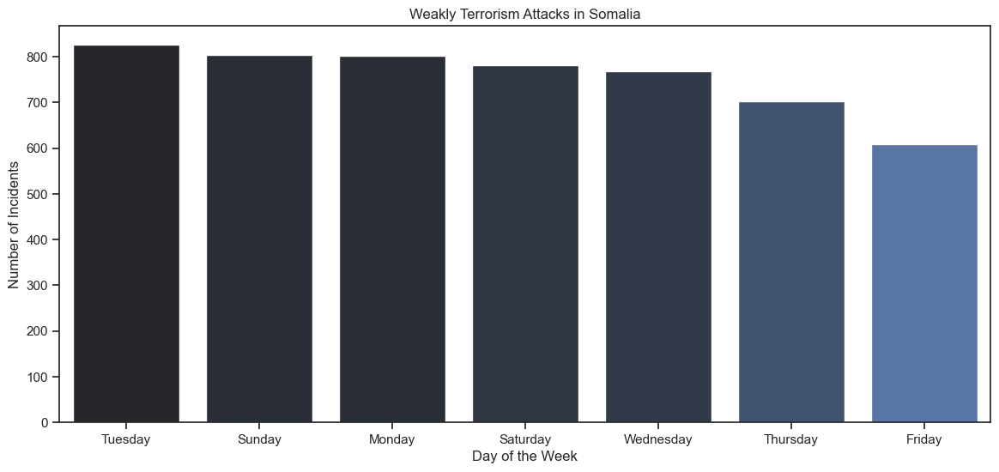

In [304]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = 'dark:b_r'

# Create a new DataFrame with counts of incidents for each day of the week
day_of_week_counts = df['day_of_week'].value_counts().reset_index()
day_of_week_counts.columns = ['day_of_week', 'incident_count']

# Sort the counts in descending order based on the incident count
day_of_week_counts = day_of_week_counts.sort_values(by='incident_count', ascending=False)

# Set the order of days of the week based on the sorted values
day_order = day_of_week_counts['day_of_week']

# Plot: Days of the week showing higher attack frequencies
plt.figure(figsize=(14, 6))
sns.barplot(data=day_of_week_counts, x='day_of_week', y='incident_count', hue='incident_count', legend=False, palette=palette, order=day_order)
plt.title("Weakly Terrorism Attacks in Somalia")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)  # Rotate x-ticks if needed
plt.show()

- ### **Do casualties increase over time?** 

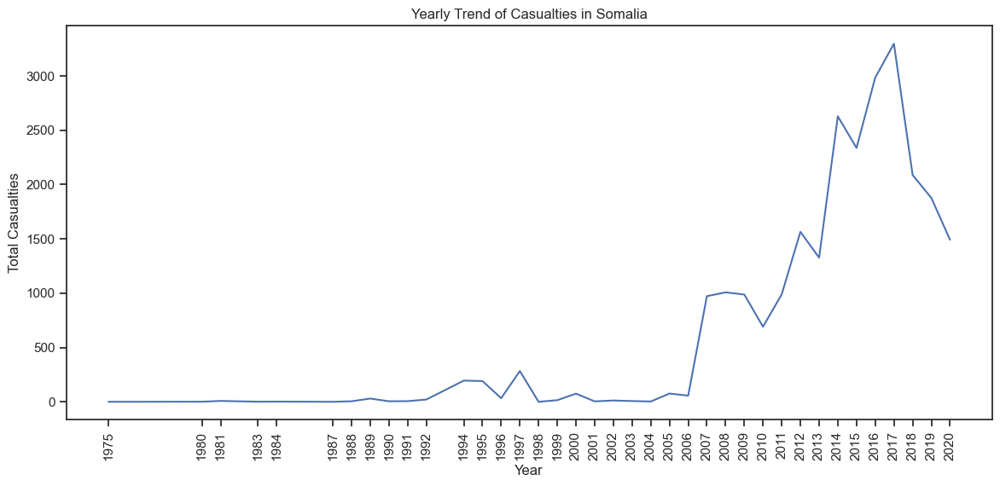

In [222]:
# Group by year and sum casualties
annual_casualties = df.groupby('year')['total_casualties'].sum()

# Visualization
plt.figure(figsize=(14, 6))
sns.lineplot(x=annual_casualties.index, y=annual_casualties.values)
plt.title('Yearly Trend of Casualties in Somalia')
plt.xlabel('Year')
plt.ylabel('Total Casualties')
plt.xticks(annual_casualties.index)
plt.xticks(rotation=90)
plt.show()

- #### **Are suicide attacks more frequent in certain months?**  

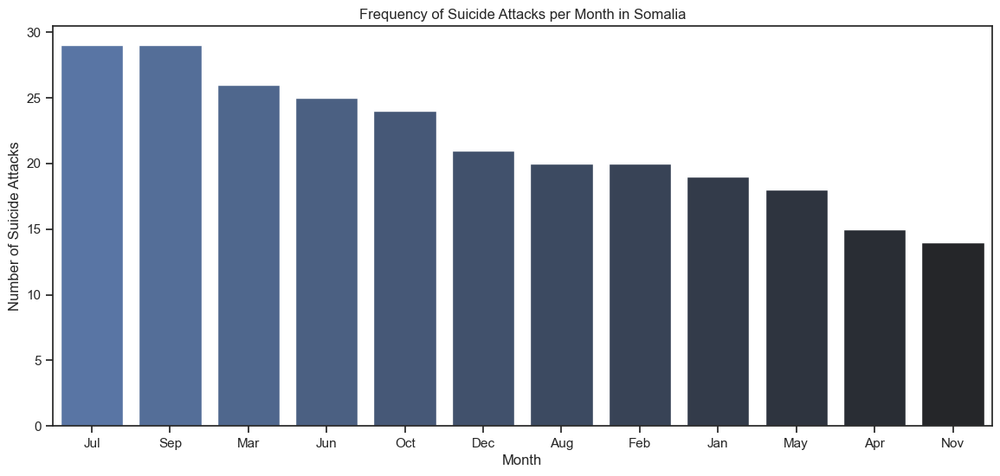

In [223]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Count suicide attacks per month
monthly_suicide_attacks = df[df['suicide'] == 1]['month_name'].value_counts().sort_index()
monthly_suicide_attacks = monthly_suicide_attacks.sort_values(ascending=False)
# Visualization
plt.figure(figsize=(14, 6))
sns.barplot(x=monthly_suicide_attacks.index, y=monthly_suicide_attacks.values, palette=palette)
plt.title('Frequency of Suicide Attacks per Month in Somalia')
plt.xlabel('Month')
plt.ylabel('Number of Suicide Attacks')
plt.xticks(monthly_suicide_attacks.index)
plt.show()


## **2. Geospatial Analysis**


- ### **Which Regions & Cities have the most Terrorism attacks?**  

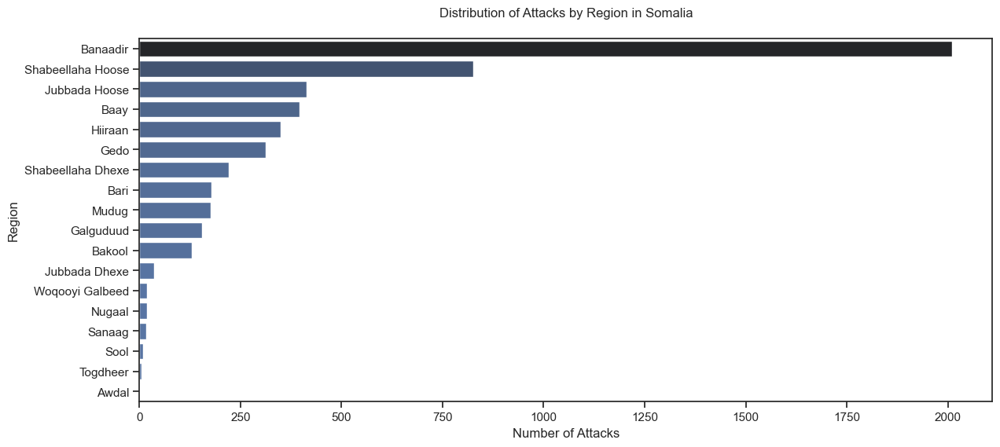

In [309]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = 'dark:b_r'

df_reg = df[df['region']!= 'Unknown']
# Count attacks by region
region_attacks = df_reg['region'].value_counts().reset_index()
region_attacks.columns = ['region', 'attack_count']
region_attacks.sort_values(by='attack_count', ascending=False, inplace=True)

# Visualization
plt.figure(figsize=(14, 6))

# Create the bar plot for attack counts by region
sns.barplot(x='attack_count', y='region', hue='attack_count', legend=False, data=region_attacks, palette=palette)

# Set plot title and labels
plt.title('Distribution of Attacks by Region in Somalia', pad=20)
plt.xlabel('Number of Attacks')
plt.ylabel('Region')
plt.xticks(rotation=0)
# Show the plot
plt.show()

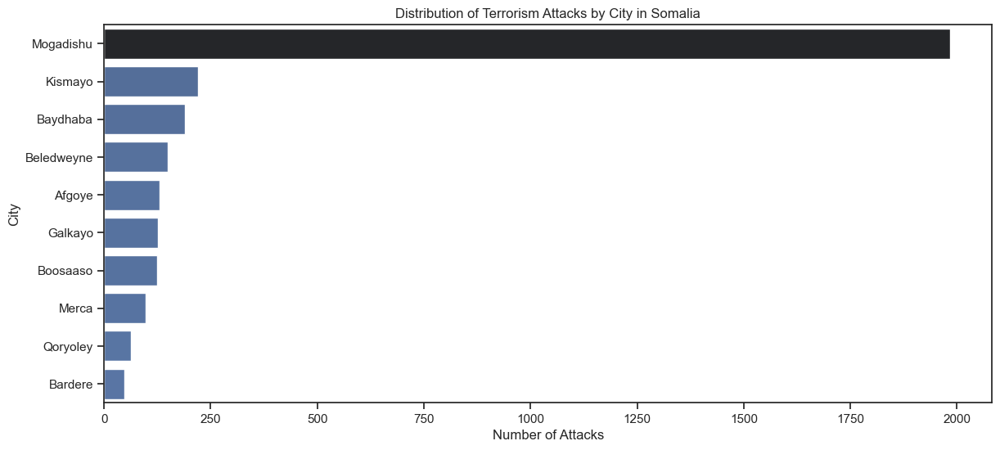

In [310]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = 'dark:b_r'
df_cit = df[df['city']!= 'Unknown']
# Count attacks by city
city_attacks = df_cit['city'].value_counts().reset_index()
city_attacks.columns = ['city', 'attack_count']
city_attacks.sort_values(by='attack_count', ascending=False, inplace=True)

# Filter for the top 20 cities
top_20_cities = city_attacks.head(10)

# Visualization
plt.figure(figsize=(14, 6))

# Create the bar plot for attack counts by top 15 cities
sns.barplot(x='attack_count', y='city', data=top_20_cities, hue='attack_count', legend=False,  palette=palette)

# Set plot title and labels
plt.title('Distribution of Terrorism Attacks by City in Somalia')
plt.xlabel('Number of Attacks')
plt.ylabel('City')
plt.xticks(rotation=0)
# Show the plot
plt.show()


- ### **What cities are the primary hotspots for terrorist Attacks?**  

In [227]:
# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.long, df.lat))

# Create a map centered around the average coordinates
map_center = [df['lat'].mean(), df['long'].mean()]
m = folium.Map(location=map_center, zoom_start=6)

# Add marker cluster to group nearby markers
marker_cluster = MarkerCluster().add_to(m)

# Add markers to the map
for _, row in gdf.iterrows():
    folium.CircleMarker(
        location=(row['lat'], row['long']),
        radius=3,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
        popup=f"City: {row['city']}, Attacks: {row['eventid']}"
    ).add_to(marker_cluster)

# Display map inline in Jupyter
m

- ### **What percentage of attacks occur in coastal, border, and other Cities?**  

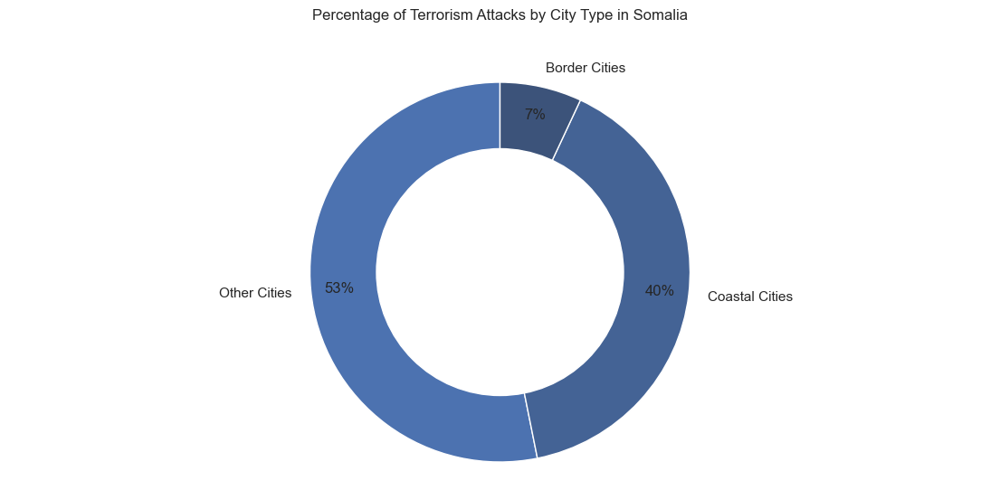

In [312]:
# Set the Seaborn theme and color palette
sns.set_theme(style='ticks')
palette = sns.color_palette('dark:b_r')

# Define coastal and border cities
coastal_cities = ['Mogadishu', 'Kismaayo', 'Baardheere', 'Hobyo', 'Qandala', 
                  'Bender Qassim', 'Baraawe', 'Marka', 'Laas Qoray', 'Boosaaso', 'Gaalkacyo',
                  'Eyl', 'Xarardheere']

border_cities = ['Buulaxaawo', 'Ceelwaaq', 'Doolow', 'Luuq', 'Beledxaawo', 
                 'Dhuusamareeb', 'Baydhaba', 'Garbahaareey', 'Beledweyne',
                 'Dhoobleey', 'Caabudwaaq']

# Create a new column to classify city types
df['city_type'] = 'Other Cities'  # Default type
df.loc[df['city'].isin(coastal_cities), 'city_type'] = 'Coastal Cities'
df.loc[df['city'].isin(border_cities), 'city_type'] = 'Border Cities'

# Count the number of attacks by city type
city_counts = df['city_type'].value_counts(normalize=True).reset_index()
city_counts.columns = ['city_type', 'percentage']

# Visualization
plt.figure(figsize=(14, 6))

# Create the pie chart
plt.pie(city_counts['percentage'], labels=city_counts['city_type'],
        colors=palette, autopct='%1.0f%%', startangle=90, pctdistance=0.85)

# Draw a circle at the center of pie to make it look like a donut
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.title('Percentage of Terrorism Attacks by City Type in Somalia', pad=35)
plt.show()

- ### **What are Percentage of Terrorism Attacks by Region**

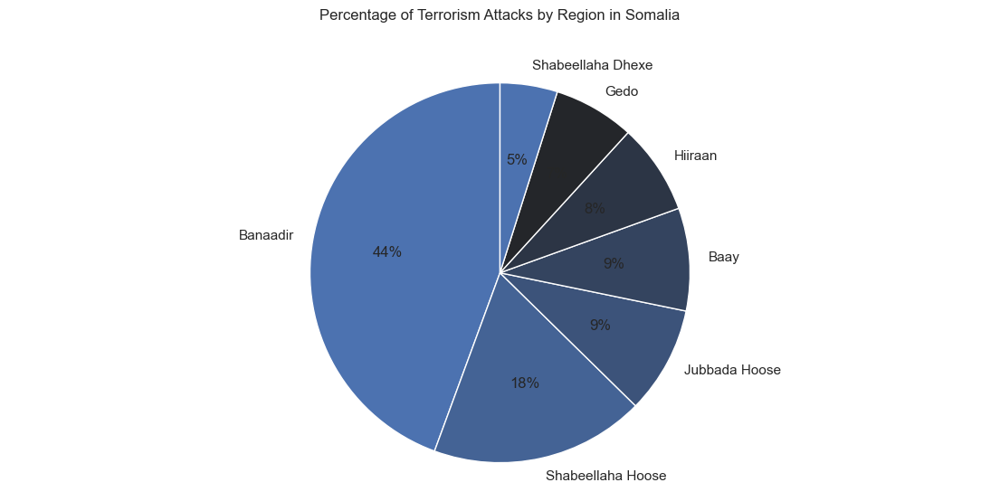

In [229]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = sns.color_palette('dark:b_r')  # Get the palette from Seaborn

# Assuming you have a column 'region' categorizing regions
region_distribution = df['region'].value_counts().head(7)

# Visualization
plt.figure(figsize=(14, 6))
# Create a pie chart
plt.pie(region_distribution, labels=region_distribution.index, autopct='%1.0f%%', startangle=90, colors=palette)
plt.title('Percentage of Terrorism Attacks by Region in Somalia', pad=35)
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.
plt.show()

### **Are There Emerging Hotspots Over Time?**

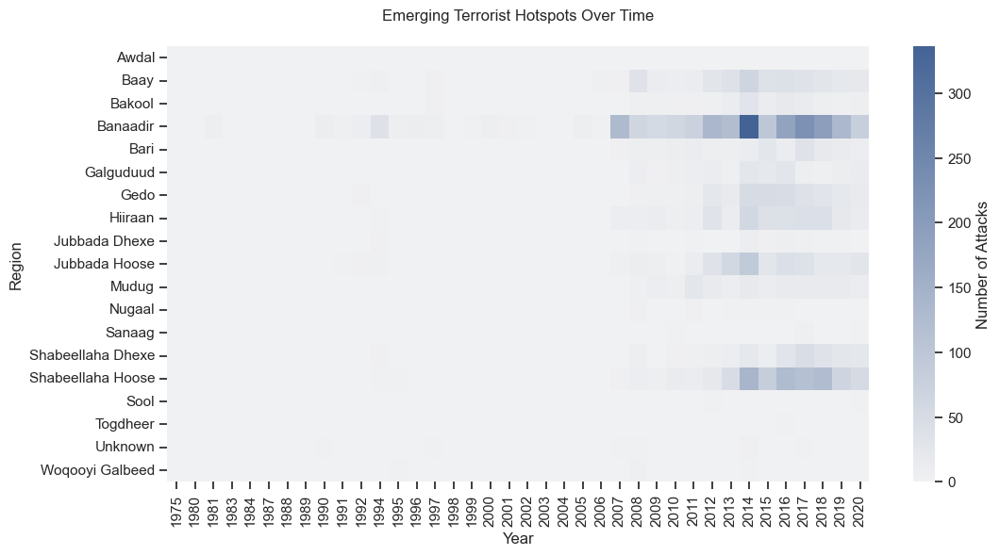

In [231]:
# Set the Seaborn theme and color palette
sns.set_theme(style='ticks')
palette = sns.color_palette('dark:b_r')

# Create a pivot table for attack density over years
density_over_time = df.groupby(['region', 'year']).size().unstack(fill_value=0)

# Create a heatmap with the dark:b_r palette
plt.figure(figsize=(12, 6))

# Create a custom colormap using the specified palette
cmap = sns.light_palette(palette[1], as_cmap=True)

# Draw the heatmap
sns.heatmap(density_over_time, cmap=cmap, cbar_kws={'label': 'Number of Attacks'})
plt.title('Emerging Terrorist Hotspots Over Time', pad=20)
plt.xlabel('Year')
plt.ylabel('Region')
plt.show()

## **3. Attack Analysis**

- #### **What are the most common attack types in Somalia?**  

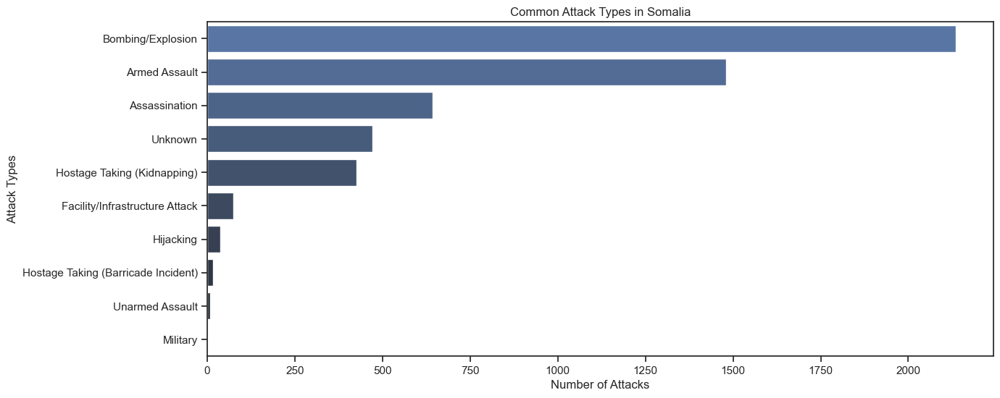

In [232]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Count the number of attacks by state
attack_types = df['attack_type'].value_counts().reset_index()
attack_types.columns = ['attack_type', 'attack_count']

# Get the top 10 states and cities with the highest number of attacks
attack_types = attack_types.head(10)


# Plotting the top states
plt.figure(figsize=(14, 6))
sns.barplot(x='attack_count', y='attack_type', data=attack_types, palette= palette)
plt.title('Common Attack Types in Somalia')
plt.xlabel('Number of Attacks')
plt.ylabel('Attack Types')
plt.show()

- ### **What percentage of attacks use explosives?**  

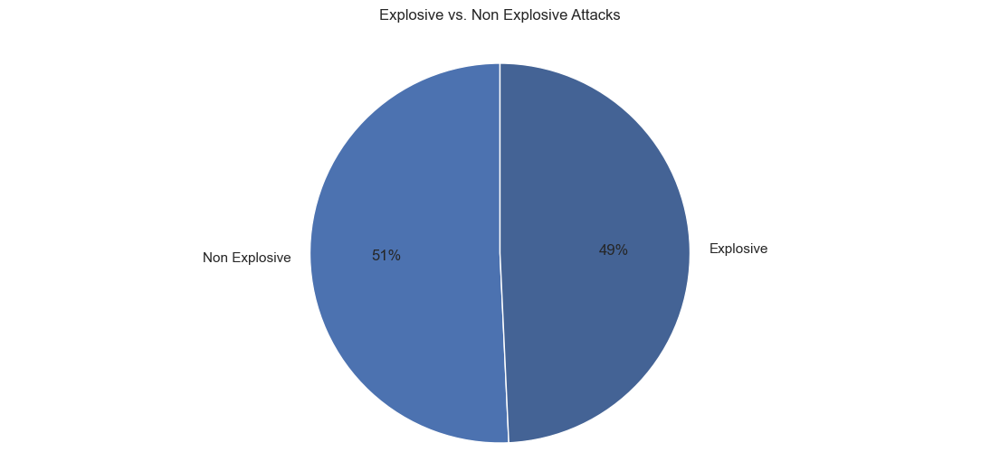

In [233]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = sns.color_palette('dark:b_r')

# Count explosive vs. non-explosive attacks
explosive_attacks = df['weapon_type'].str.contains('Explosives', case=False)
explosive_counts = explosive_attacks.value_counts()

# Prepare data for the pie chart
labels = ['Non Explosive', 'Explosive']
sizes = explosive_counts.values

# Create the pie chart
plt.figure(figsize=(14, 6))
plt.pie(sizes, labels=labels, autopct='%1.0f%%', startangle=90, colors=palette)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Explosive vs. Non Explosive Attacks', pad=20)
plt.show()

- ### **What attack types have the highest casualties?**  

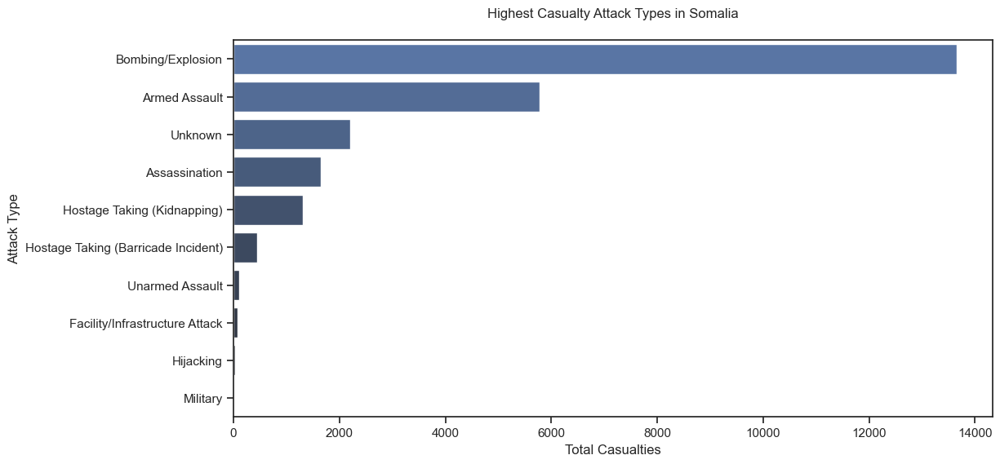

In [234]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Calculate average casualties by attack type
avg_casualties_by_type = df.groupby('attack_type')['total_casualties'].sum().sort_values(ascending=False)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_casualties_by_type.values, y=avg_casualties_by_type.index,  palette=palette)
plt.title('Highest Casualty Attack Types in Somalia', pad=20)
plt.xlabel('Total Casualties')
plt.ylabel('Attack Type')
plt.xticks(rotation=0)
plt.show()


- ### **Are certain attack types more successful?**  

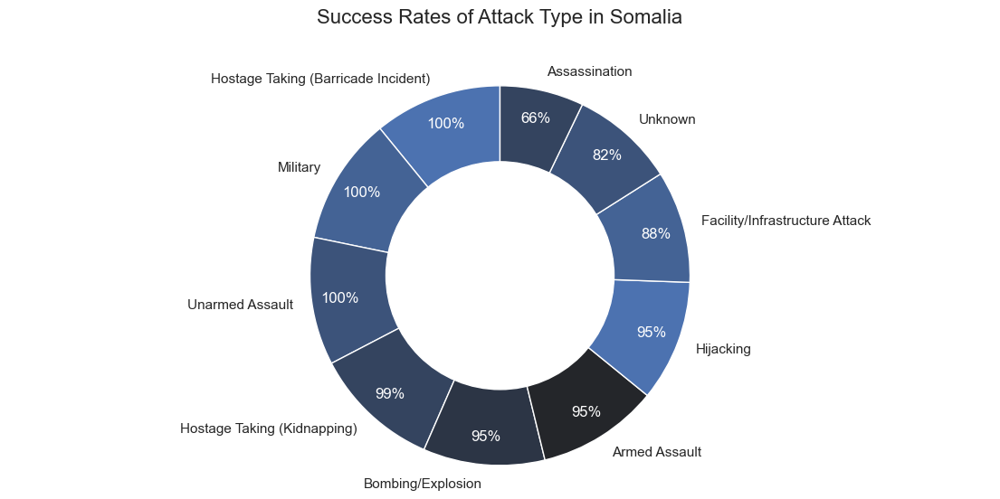

In [235]:
# Set the Seaborn theme and color palette
sns.set_theme(style='ticks')
palette = sns.color_palette('dark:b_r')  # Define the color palette

# Calculate success rates by attack type
success_rate_by_type = df.groupby('attack_type')['success'].mean().sort_values(ascending=False)

# Convert success rates to percentages
success_rate_percent = success_rate_by_type * 100

# Create a donut chart
plt.figure(figsize=(14, 6))
# Create a wedge plot with colors from the palette
wedges, texts, autotexts = plt.pie(success_rate_percent, 
                                   labels=success_rate_percent.index, 
                                   autopct='', startangle=90, pctdistance=0.85, 
                                   colors=palette)

# Draw a circle in the center to create a donut shape
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Draw the percentages on the donut chart with white font
for i, p in enumerate(autotexts):
    p.set_text(f'{success_rate_percent[i]:.0f}%')
    p.set_color('white')  # Set percentage text color to white
    p.set_fontsize(12)  # Adjust font size if needed

# Set title and adjust appearance
plt.title('Success Rates of Attack Type in Somalia', pad=35, fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that the pie chart is circular
plt.show()

- ### **How common are suicide attacks, and have they increased over time?**

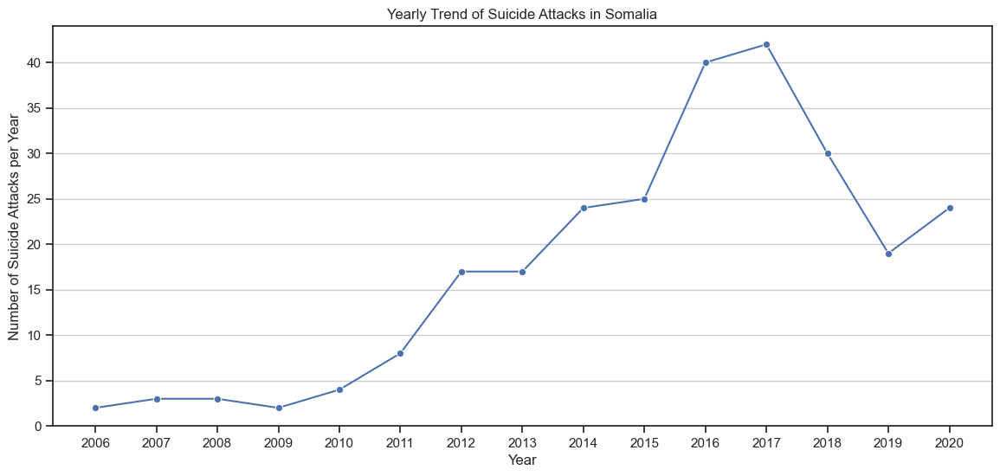

In [236]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Count suicide attacks per year
suicide_attacks_per_year = df[df['suicide'] == 1].groupby('year')['eventid'].count()

# Visualization
plt.figure(figsize=(14, 6))
sns.lineplot(x=suicide_attacks_per_year.index, y=suicide_attacks_per_year.values, marker='o', palette=palette)
plt.title('Yearly Trend of Suicide Attacks in Somalia')
plt.xlabel('Year')
plt.ylabel('Number of Suicide Attacks per Year')
plt.xticks(suicide_attacks_per_year.index)
plt.grid(axis='y')
plt.show()

- ### **Which weapon types are most common in suicide Attacks?**  

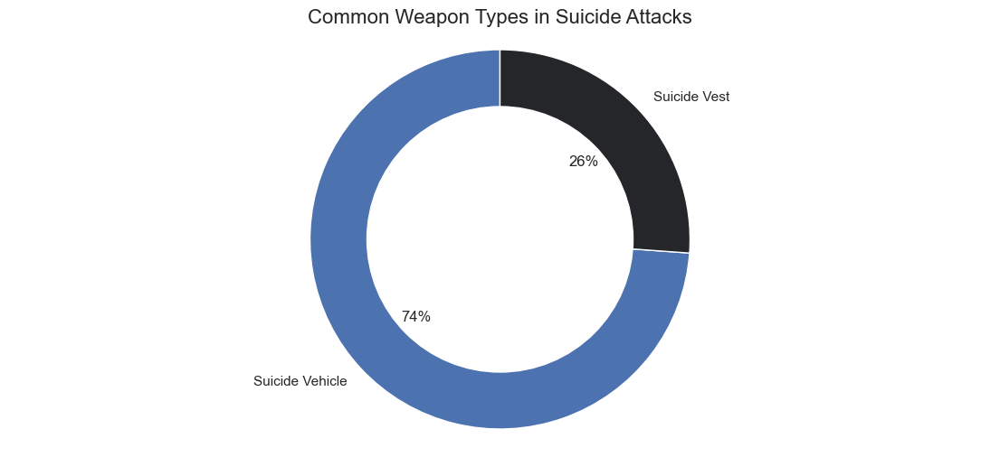

In [237]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'

# Filter for suicide attacks
suicide_attacks = df[df['suicide'] == 1]
# Count weapon types used in suicide attacks
weapon_counts = suicide_attacks['weapon_subtype'].value_counts()
# Calculate percentages
weapon_percentages = (weapon_counts / weapon_counts.sum()) * 100

# Visualization - Pie chart
plt.figure(figsize=(14, 6))
plt.pie(weapon_percentages, labels=weapon_percentages.index, autopct='%1.0f%%', startangle=90, colors=sns.color_palette(palette, len(weapon_percentages)))
# Draw a circle in the center to create a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Set title and make the pie chart circular
plt.title('Common Weapon Types in Suicide Attacks', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

- ### **Is there a correlation between attack types and specific regions?** 

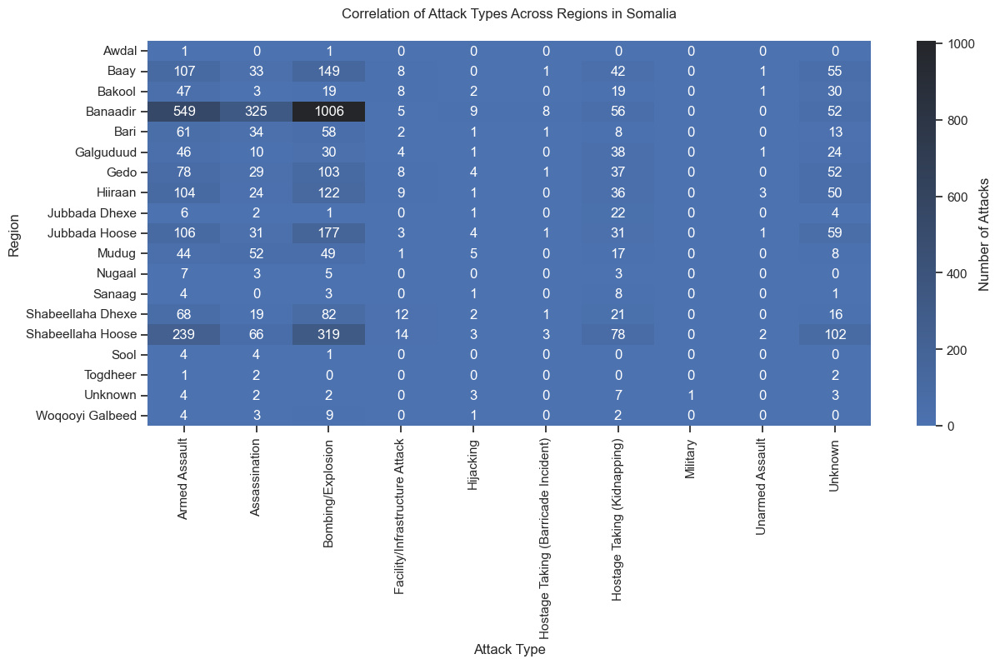

In [238]:
# Set the Seaborn theme and color palette
sns.set_theme(style='ticks')
palette = sns.color_palette('dark:b_r', as_cmap=True)  # Create a color map

# Create a pivot table for attack type distribution across regions
attack_type_region = df.pivot_table(index='region', columns='attack_type', values='eventid', aggfunc='count', fill_value=0)

# Visualization
plt.figure(figsize=(14, 6))
sns.heatmap(attack_type_region, cmap=palette, annot=True, fmt='d', cbar_kws={'label': 'Number of Attacks'})
plt.title('Correlation of Attack Types Across Regions in Somalia', pad=20)
plt.xlabel('Attack Type')
plt.ylabel('Region')
plt.xticks(rotation=90)
plt.show()

## **4. Target Type**


- ### **What are the most frequently targeted groups in Somalia?**  

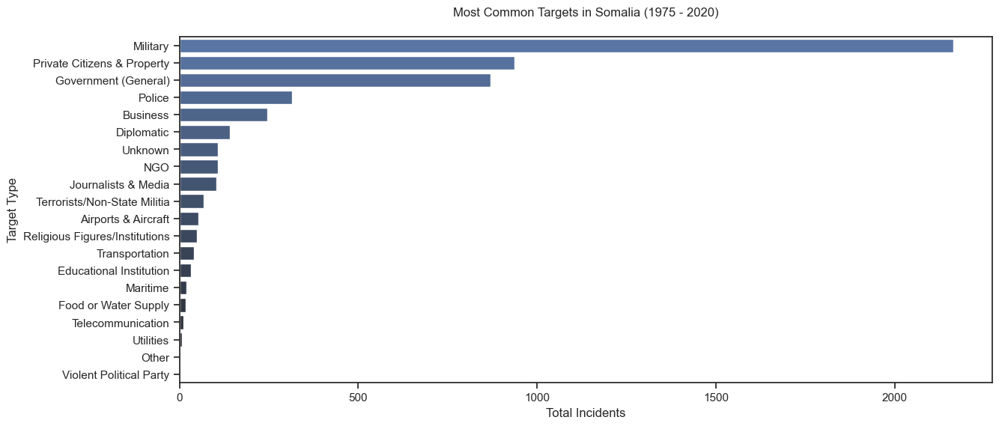

In [239]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Target types
target_types = df['target_type'].value_counts().reset_index()
target_types.columns = ['target_type', 'count']

plt.figure(figsize=(14, 6))
sns.barplot(data=target_types, x='count', y='target_type', palette=palette)
plt.title('Most Common Targets in Somalia (1975 - 2020)', pad=20)
plt.xlabel('Total Incidents')
plt.ylabel('Target Type')
plt.show()

- ### **What percentage of attacks target civilians?**  

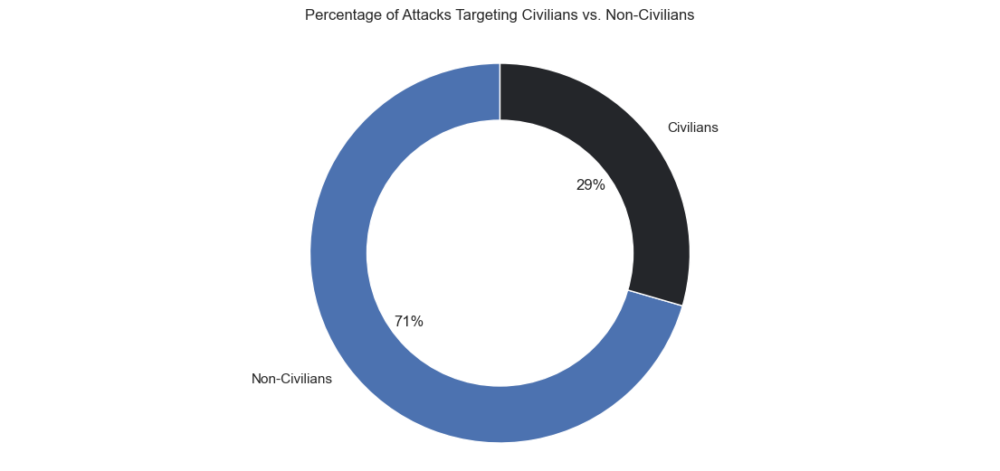

In [240]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = 'dark:b_r'

# Expanded list of keywords for civilian-related targets (non-combatants)
civilian_keywords = [
    'Civilians', 'civilian', 'Traditional Elders', 'Tribal Elder', 'Clan Elder', 'Children', 'Women', 
    'Elderly', 'Doctors', 'Journalists', 'Aid workers', 'Aid worker', 'Local Aid Worker', 'Local Aid Workers', 
    'International Aid Worker', 'International Aid Workers', 'electoral delegates', 'electoral delegate', 
    'Clan elders', 'Elders', 'cinema', 'IRC', 'WFP', 'WHO', 'UNHCR', 'IDPs', 'Schools', 'Hospitals', 'Clinics', 
    'Forieng Teachers', 'Teachers', 'Students', 'Refugees', 'IDP Camp','Humanitarian', 'Peacekeepers', 'University', 
    'NGO workers', 'Red Cross', 'UNICEF', 'Markets', 'Shops', 'Mosques', 'Churches', 'Religious Sites', 'Public Gatherings', 
    'Bus Station', 'Train Station', 'Public Transport', 'Media', 'Press', 'Peace Delegation', 'Human Rights', 'Hotel', 
    'Food Convoy', 'Residential area', 'Businessmen', 'News reporters', 'Truck', 'Refugee Camp', 'AP Correspondent', 
    'Swiss Journalist', 'Italian Christian missionaries', 'Peace Activist', 'Rally', 'Livestock Market', 
    'Film Dubbing Studio', 'TV Station', 'British TV Station', 'International aid workers', 'Convoy', 'UN Food Convoy', 
    'Horn Afrik Journalist', 'NGO employee', 'Red Crescent', 'Healthcare Workers', 'Volunteers', 'Public Figures', 
    'Neutral Parties', 'Displaced Persons', 'Medical Teams', 'Children\'s Organizations',  'Family Residence', 
    'Village Leaders', 'Neutral Mediators', 'Community Leaders',  'Public Gatherings', 'Peace Negotiators', 
    'Local Traders', 'Schoolchildren',  'Cultural Centers', 'Social Workers', 'Public Square', 'Bus Stop', 
    'Village Council', 'Cultural Events', 'Shelters', 'Islamic Cleric'
]

# Filter the dataset for civilian-related attacks
civilian_attacks = df['target'].str.contains('|'.join(civilian_keywords), case=False, na=False)

# Create a new DataFrame for civilian and non-civilian categorization
df_attack_types = df.copy()  # Make a copy of the original DataFrame
df_attack_types['target_type'] = 'Non-Civilians'  # Default value
df_attack_types.loc[civilian_attacks, 'target_type'] = 'Civilians'  # Assign civilians where relevant

# Calculate the percentage of attacks targeting civilians
target_counts = df_attack_types['target_type'].value_counts(normalize=True) * 100

# Define labels for pie chart
labels = target_counts.index

# Visualization - Pie chart
plt.figure(figsize=(14, 6))
plt.pie(target_counts, labels=labels, autopct='%1.0f%%', startangle=90, colors=sns.color_palette(palette, len(target_counts)))

# Donut shape
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Set title and equal aspect ratio
plt.title('Percentage of Attacks Targeting Civilians vs. Non-Civilians', pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

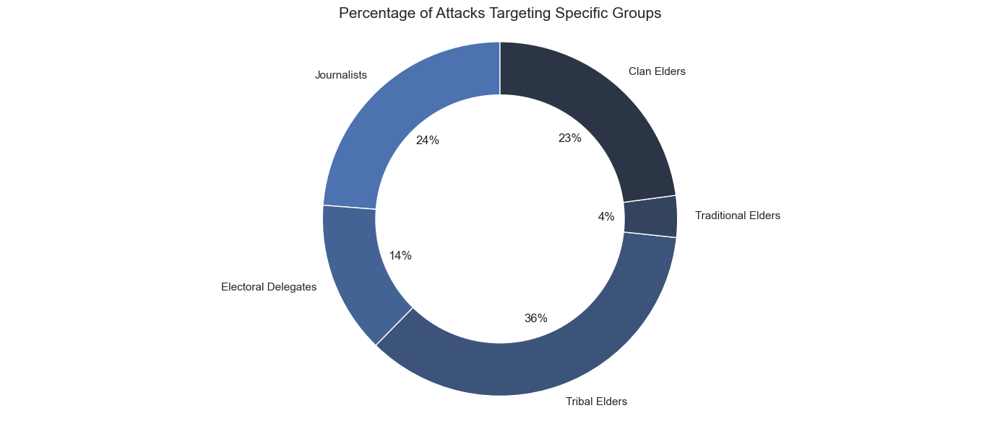

In [241]:
# Set the Seaborn theme
sns.set_theme(style='ticks')

# Define the job titles you want to analyze
job_titles = [
    'Journalists',
    'Electoral Delegates',
    'Tribal Elders',
    'Traditional Elders',
    'Clan Elders'
]

# Expanded keywords for the specific job titles
keywords_mapping = {
    'Journalists': ['Journalist', 'Press', 'Media', 'Reporter', 'Correspondent', 
                    'News', 'Journal', 'Writer', 'Editor', 'Radio', 'TV Director', 
                    'TV Presenter', 'News Anchor', 'Photojournalist', 'Freelance Journalist', 
                    'Investigative Journalist', 'Broadcast Journalist', 'Digital Journalist'],
    'Electoral Delegates': ['Electoral Delegates', 'Electoral Delegate', 
                            'Election Delegate', 'Polling Agent', 'Voting Delegate'],
    'Tribal Elders': ['Tribal Elder', 'Clan Elder', 'Elders', 
                      'Community Leader', 'Tribal Leader', 'Chief'],
    'Traditional Elders': ['Traditional Elders', 'Cultural Leader', 
                           'Cultural Elder', 'Heritage Elder'],
    'Clan Elders': ['Clan Elder', 'Family Elder', 'Elder', 'Patriarch', 'Matriarch']
}

# Prepare a list to hold the counts
attacks_counts = []

# Calculate counts for each job title
for job_title, keywords in keywords_mapping.items():
    # Create a regex pattern for filtering
    pattern = '|'.join(keywords)
    
    # Filter the DataFrame for attacks targeting the job title
    attacks_count = df[df['target'].str.contains(pattern, case=False, na=False)].shape[0]
    
    # Append the result to the list
    attacks_counts.append({'job_title': job_title, 'count': attacks_count})

# Convert the counts to a DataFrame
df_attacks_counts = pd.DataFrame(attacks_counts)

# Calculate the total number of attacks for percentage calculation
total_attacks = df.shape[0]

# Calculate percentages
df_attacks_counts['percentage'] = (df_attacks_counts['count'] / total_attacks) * 100

# Visualization - Pie chart
plt.figure(figsize=(14, 6))
plt.pie(df_attacks_counts['percentage'], labels=df_attacks_counts['job_title'], 
        autopct='%1.0f%%', startangle=90, colors=sns.color_palette('dark:b_r'))

# Draw a circle in the center to create a donut shape (optional)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Set title
plt.title('Percentage of Attacks Targeting Specific Groups', fontsize=15)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()  # Adjust the layout
plt.show()

- ### **Which target types see the most casualties?**  

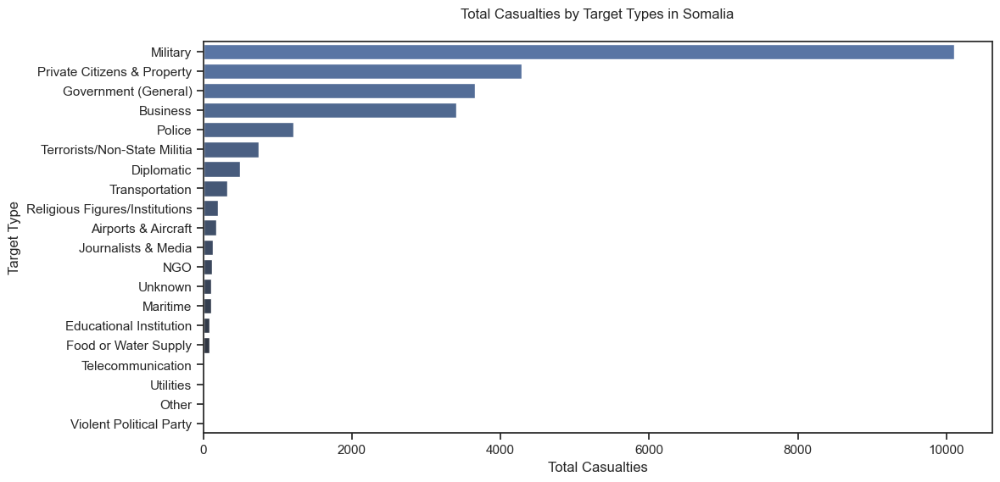

In [242]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Calculate average casualties by target type
avg_casualties_by_target = df.groupby('target_type')['total_casualties'].sum().sort_values(ascending=False)

# Visualization - Bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_casualties_by_target.values, y=avg_casualties_by_target.index, palette=palette)
plt.title('Total Casualties by Target Types in Somalia', pad=20)
plt.xlabel('Total Casualties')
plt.ylabel('Target Type')
plt.xticks(rotation=0)
plt.show()

- ### **What are the most frequently targets?**  

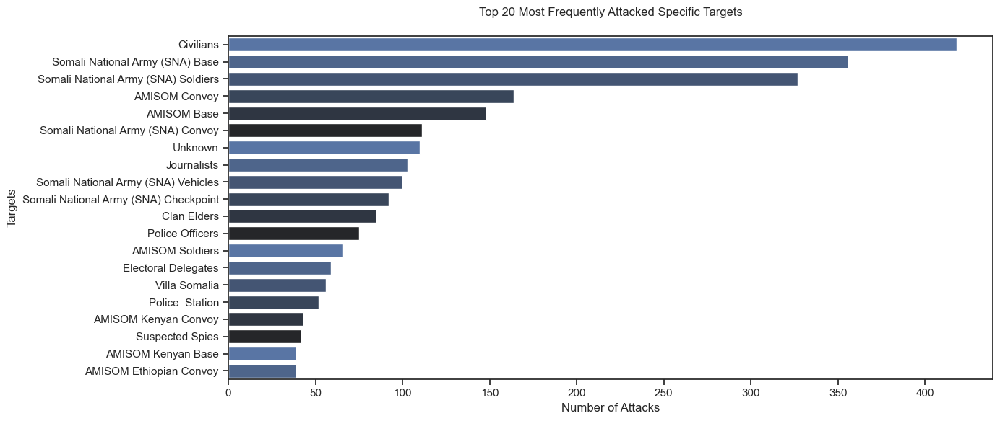

In [276]:
# Set the Seaborn theme and color palette
sns.set_theme(style='ticks')
palette = sns.color_palette('dark:b_r')

# Count specific targets and sort by the number of attacks (descending order)
specific_target_counts = df['target'].value_counts().sort_values(ascending=False)

# Select the top 20 targets
top_20_targets = specific_target_counts.head(20)

# Visualization - Bar chart of the top 20 specific targets
plt.figure(figsize=(14, 6))
sns.barplot(x=top_20_targets.values, y=top_20_targets.index, palette=palette)
plt.title('Top 20 Most Frequently Attacked Specific Targets', pad=20)
plt.xlabel('Number of Attacks')
plt.ylabel('Targets')
plt.xticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()

## **5. Perpetrator Analysis**

- ### **Which terrorist groups are most active in Somalia?** 

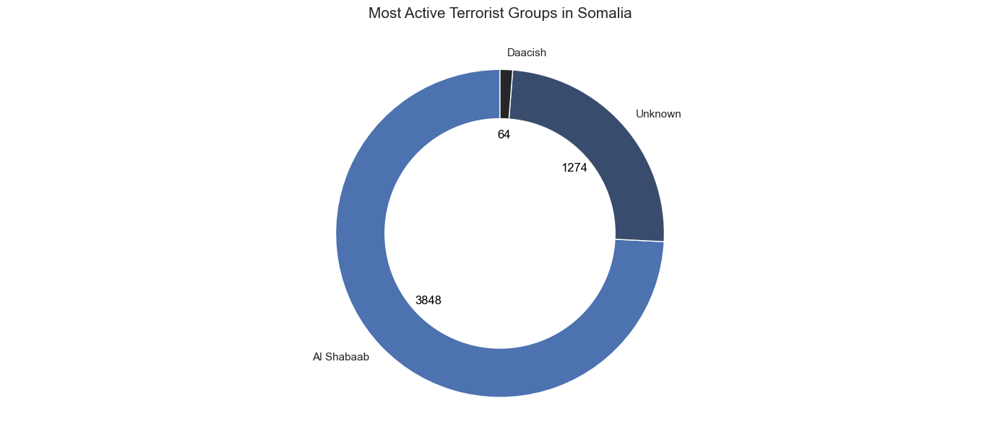

In [244]:
# Set the Seaborn theme
sns.set_theme(style='ticks')

# Count attacks by perpetrator groups
group_counts = df['group_name'].value_counts()

# Select the top 3 groups
top_groups = group_counts.head(3)

# Visualization - Donut chart
plt.figure(figsize=(14, 6))

# Create a wedge plot
wedges, texts, autotexts = plt.pie(top_groups.values, labels=top_groups.index, 
                                   autopct='', startangle=90, colors=sns.color_palette('dark:b_r', len(top_groups)))

# Draw a circle in the center to create a donut shape
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Draw the percentages on the donut chart
for i, p in enumerate(autotexts):
    p.set_text(f'{top_groups.values[i]}')
    p.set_color('black')  # Set text color for better readability

# Set title and equal aspect ratio
plt.title('Most Active Terrorist Groups in Somalia', pad=35, fontsize=15)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the plot
plt.tight_layout()  # Adjust the layout
plt.show()

- ### **How has the influence of groups like Al-Shabaab evolved?**  

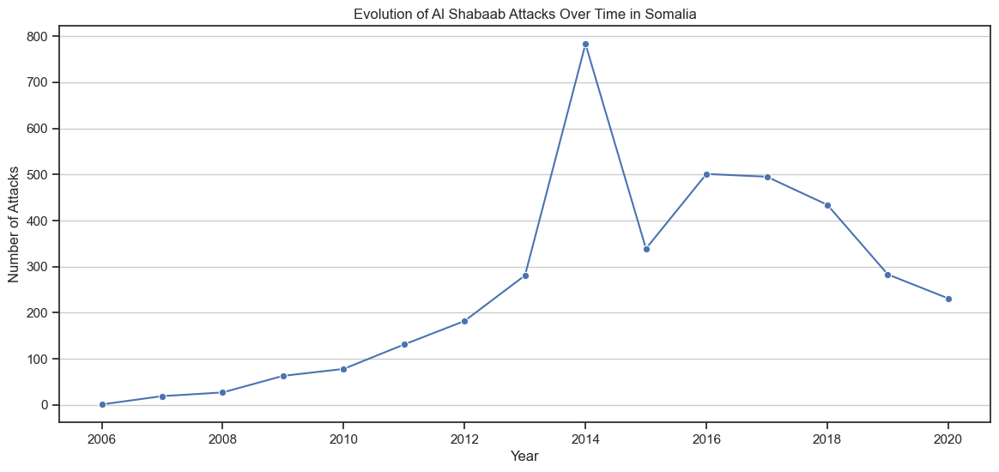

In [245]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Filter attacks by Al-Shabaab
al_shabaab_attacks = df[df['group_name'] == 'Al Shabaab']

# Count attacks by year
al_shabaab_by_year = al_shabaab_attacks['year'].value_counts().sort_index()

# Visualization - Line graph
plt.figure(figsize=(14, 6))
sns.lineplot(x=al_shabaab_by_year.index, y=al_shabaab_by_year.values, marker='o', palette=palette)
plt.title('Evolution of Al Shabaab Attacks Over Time in Somalia')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=0)
plt.grid(axis='y')  # Set to 'y' for horizontal grid lines only
plt.show()

- ### **What are the most common attack types used by the top Terrorist Groups in Somalia?**

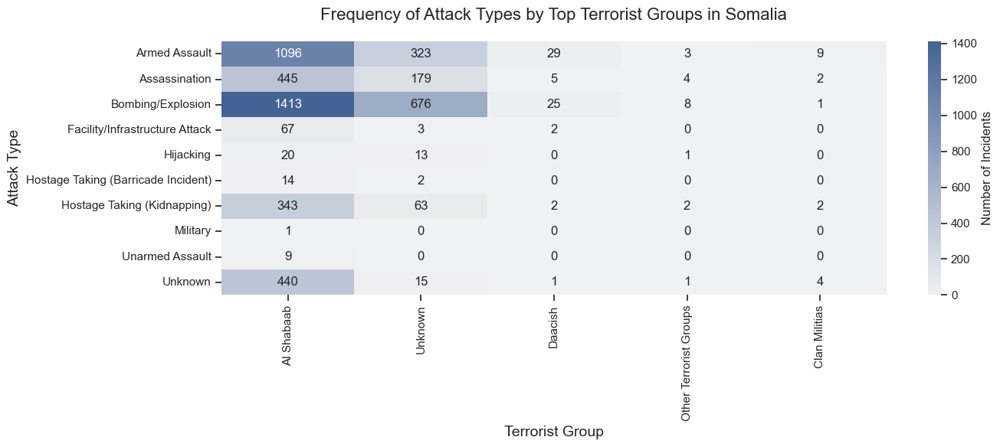

In [246]:
# Set the Seaborn theme and color palette
sns.set_theme(style='ticks')
palette = sns.color_palette('dark:b_r')

# Group by terrorist group and attack type, then count the number of incidents
attack_type_group = df.groupby(['group_name', 'attack_type']).size().unstack(fill_value=0)

# Calculate the total number of incidents per terrorist group and get the top five
top_five_groups = attack_type_group.sum(axis=1).nlargest(5).index
attack_type_group_top_five = attack_type_group.loc[top_five_groups]

# Create a custom colormap using the specified palette
cmap = sns.light_palette(palette[1], as_cmap=True)

# Plotting the heatmap with axes swapped
plt.figure(figsize=(14, 6))
sns.heatmap(attack_type_group_top_five.T, annot=True, fmt='d', cmap=cmap, cbar_kws={'label': 'Number of Incidents'})

# Customize the plot
plt.title('Frequency of Attack Types by Top Terrorist Groups in Somalia', pad=20, fontsize=16)
plt.xlabel('Terrorist Group', fontsize=14)
plt.ylabel('Attack Type', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
# Show the plot
plt.show()

### **6. Weapon Effectiveness**

- ### **What are the most commonly used weapons in terrorism attacks?**  

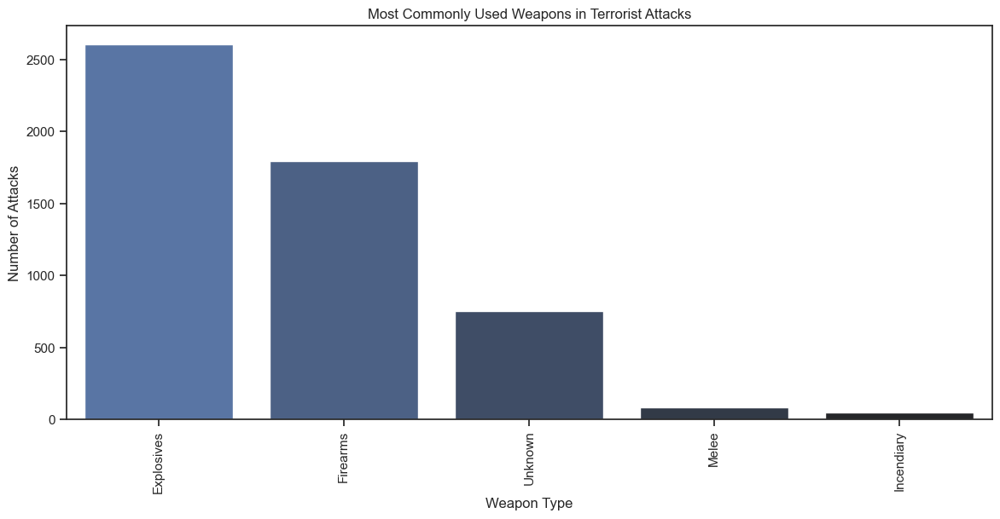

In [247]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Count the number of attacks by weapon type
weapon_counts = df['weapon_type'].value_counts()

# Visualization - Bar chart
plt.figure(figsize=(14, 6))
sns.barplot(x=weapon_counts.index[:5], y=weapon_counts.values[:5], palette=palette)
plt.title('Most Commonly Used Weapons in Terrorist Attacks')
plt.xlabel('Weapon Type')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=90)
plt.show()



- ### **What percentage of attacks use Explosives vs. Firearms?**  

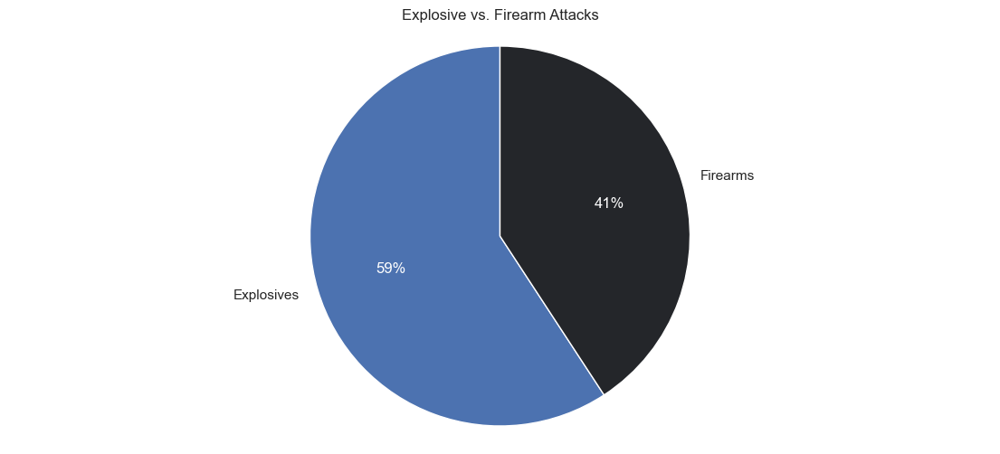

In [248]:
# Set the Seaborn theme
sns.set_theme(style='ticks')

# Filter for explosives and firearms
explosives_firearms = df['weapon_type'].isin(['Explosives', 'Firearms'])

# Count occurrences of each weapon type (Explosives vs Firearms)
weapon_comparison = df[explosives_firearms]['weapon_type'].value_counts()

# Visualization - Pie chart
plt.figure(figsize=(14, 6))
wedges, texts, autotexts = plt.pie(
    weapon_comparison, 
    labels=weapon_comparison.index, 
    autopct='',  # Temporarily disable automatic percentage display
    startangle=90, 
    colors=sns.color_palette(palette, len(weapon_comparison))
)

# Draw the percentages on the pie chart
for i, p in enumerate(autotexts):
    p.set_text(f'{weapon_comparison.values[i] / weapon_comparison.sum() * 100:.0f}%')  # Set text to show percentage
    p.set_color('white')  # Set text color to white

plt.title('Explosive vs. Firearm Attacks')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


- ### **Which weapons cause the most Casualties?**  

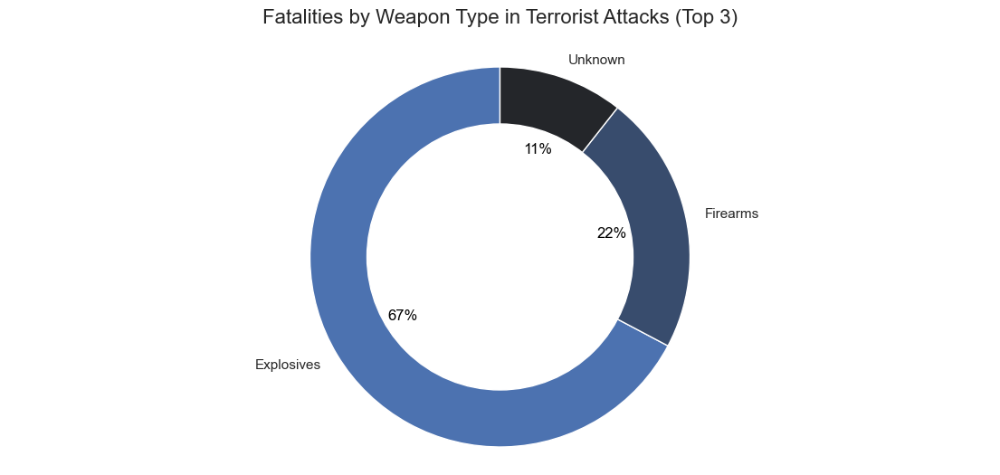

In [249]:
# Set the Seaborn theme
sns.set_theme(style='ticks')

# Group by weapon type and calculate total fatalities
fatalities_by_weapon = df.groupby('weapon_type')['total_casualties'].sum().sort_values(ascending=False)

# Get the top 3 weapon types
top_weapons = fatalities_by_weapon.head(3)

# Create the donut chart
plt.figure(figsize=(14, 6))
wedges, texts, autotexts = plt.pie(
    top_weapons, 
    labels=top_weapons.index, 
    autopct='',  # Temporarily disable automatic percentage display
    startangle=90, 
    colors=sns.color_palette(palette, len(top_weapons))
)

# Draw a circle in the center to create a donut shape
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Draw the percentages on the donut chart
for i, p in enumerate(autotexts):
    p.set_text(f'{top_weapons.values[i] / top_weapons.sum() * 100:.0f}%')  # Set text to show percentage
    p.set_color('black')  # Set text color for better readability

# Set title and equal aspect ratio
plt.title('Fatalities by Weapon Type in Terrorist Attacks (Top 3)', pad=20, fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that the pie chart is circular
plt.show()

- ### **What is the success rate for attacks using Firearms vs. Explosives?**  

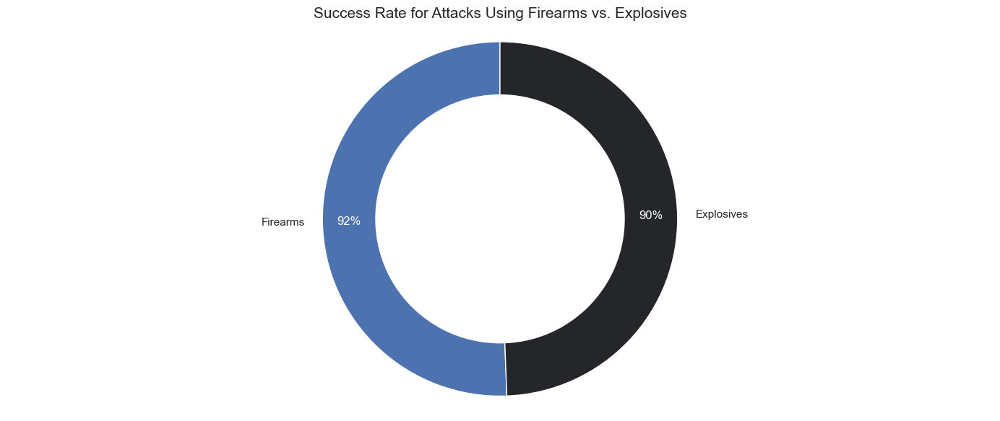

In [250]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = 'dark:b_r'

# Filter the DataFrame for firearms and explosives
firearms_attacks = df[df['weapon_type'].str.contains('Firearms', case=False, na=False)]
explosives_attacks = df[df['weapon_type'].str.contains('Explosives', case=False, na=False)]

# Calculate success rates
firearms_success_rate = firearms_attacks['success'].mean() * 100  # Convert to percentage
explosives_success_rate = explosives_attacks['success'].mean() * 100  # Convert to percentage

# Prepare data for visualization
success_rates = pd.DataFrame({
    'Weapon Type': ['Firearms', 'Explosives'],
    'Success Rate (%)': [firearms_success_rate, explosives_success_rate]
})

# Create a donut chart
plt.figure(figsize=(14, 6))

# Create wedges
wedges, texts, autotexts = plt.pie(success_rates['Success Rate (%)'], 
                                   labels=success_rates['Weapon Type'], 
                                   autopct='', startangle=90, pctdistance=0.85,
                                   colors=sns.color_palette(palette, len(success_rates)))

# Draw a circle in the center to create a donut shape
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Draw the percentages on the donut chart
for i, p in enumerate(autotexts):
    p.set_text(f'{success_rates["Success Rate (%)"].values[i]:.0f}%')
    p.set_color('white')  # Set text color to white for better readability

# Set title
plt.title('Success Rate for Attacks Using Firearms vs. Explosives', fontsize=15)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()  # Adjust the layout
plt.show()

- ### **Are suicide bombings more effective than other methods?**  

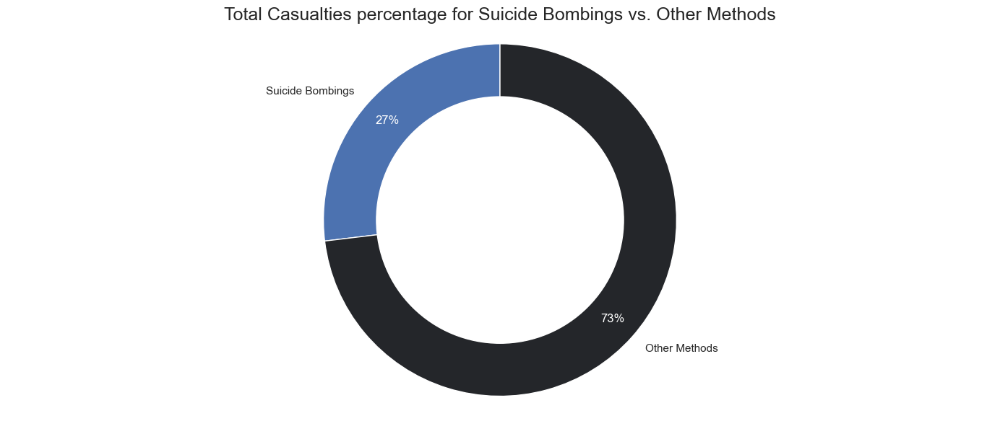

In [251]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = 'dark:b_r'

# Filter the DataFrame for suicide bombings and other methods
suicide_bombings = df[df['suicide'] == 1]
other_methods = df[df['suicide'] == 0]

# Calculate total casualties
total_casualties = pd.DataFrame({
    'Method': ['Suicide Bombings', 'Other Methods'],
    'Total Casualties': [suicide_bombings['total_casualties'].sum(), 
                         other_methods['total_casualties'].sum()]
})

# Calculate percentages
total_casualties['Percentage'] = (total_casualties['Total Casualties'] / total_casualties['Total Casualties'].sum()) * 100

# Create a donut chart
plt.figure(figsize=(14, 6))

# Create wedges
wedges, texts, autotexts = plt.pie(total_casualties['Percentage'], 
                                   labels=total_casualties['Method'], 
                                   autopct='', startangle=90, pctdistance=0.85,
                                   colors=sns.color_palette(palette, len(total_casualties)))

# Draw a circle in the center to create a donut shape
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Draw the percentages on the donut chart
for i, p in enumerate(autotexts):
    p.set_text(f'{total_casualties["Percentage"].values[i]:.0f}%')  # Show percentage with one decimal place
    p.set_color('white')  # Set text color to white for better readability

# Set title
plt.title('Total Casualties percentage for Suicide Bombings vs. Other Methods', fontsize=18)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()  # Adjust the layout
plt.show()


- ### **What is the Correlation Between Attack Type and Weapon Used?**

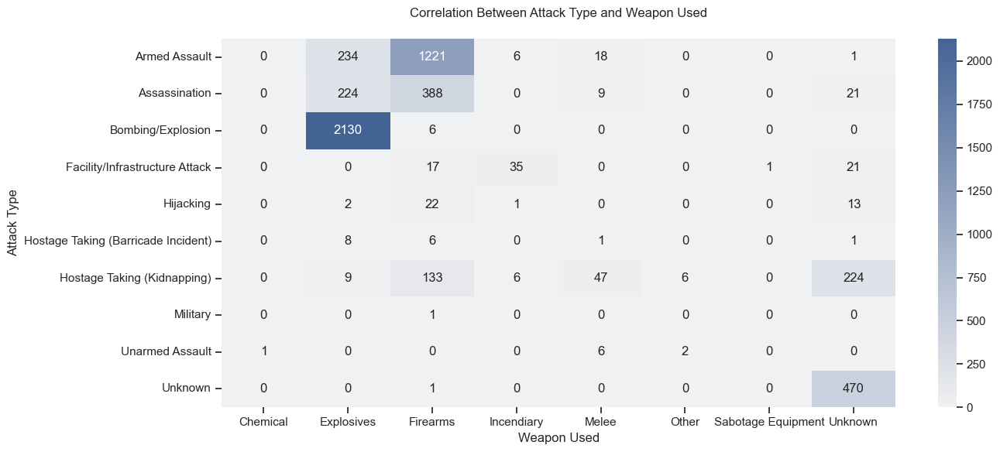

In [252]:
# Set the Seaborn theme and color palette
sns.set_theme(style='ticks')
palette = sns.color_palette('dark:b_r')
# Create a crosstab of attack type and weapon type
attack_weapon_crosstab = pd.crosstab(df['attack_type'], df['weapon_type'])

# Create a custom colormap using the specified palette
cmap = sns.light_palette(palette[1], as_cmap=True)

plt.figure(figsize=(14, 6))
sns.heatmap(attack_weapon_crosstab, cmap=cmap, annot=True, fmt='d')
plt.title('Correlation Between Attack Type and Weapon Used', pad=20)
plt.xlabel('Weapon Used')
plt.ylabel('Attack Type')
plt.tight_layout()
plt.show()

- ### **What are the percentages of different suicide attacks types?**

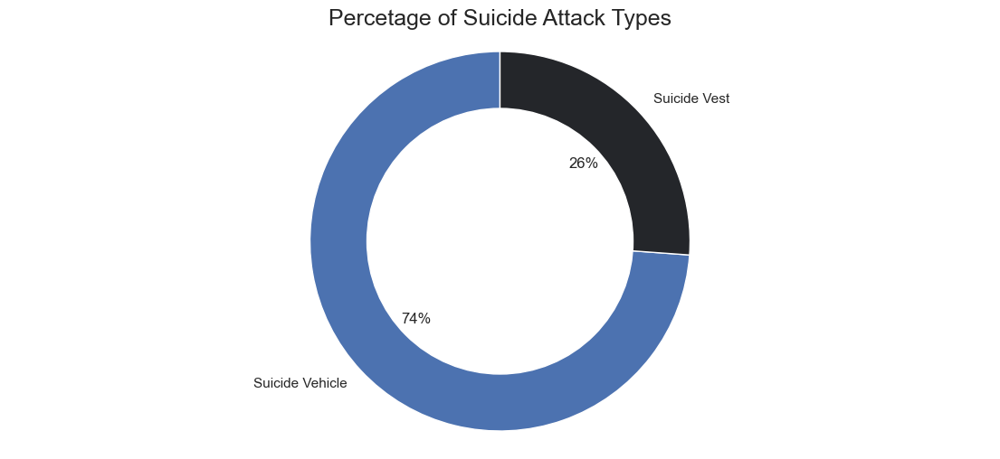

In [253]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Filter for suicide attacks
suicide_attacks = df[df['suicide'] == 1]

# Count weapon types used in suicide attacks
weapon_counts = suicide_attacks['weapon_subtype'].value_counts()

# Calculate percentages
weapon_percentages = (weapon_counts / weapon_counts.sum()) * 100

# Visualization - Pie chart
plt.figure(figsize=(14, 6))
plt.pie(weapon_percentages, labels=weapon_percentages.index, 
        autopct='%1.0f%%', startangle=90, 
        colors=sns.color_palette(palette, len(weapon_percentages)))

# Draw a circle in the center to create a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Set title and make the pie chart circular
plt.title('Percetage of Suicide Attack Types', fontsize=18)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

- ### **What is the percentage distribution of weapon subtypes used in assassination attacks?**

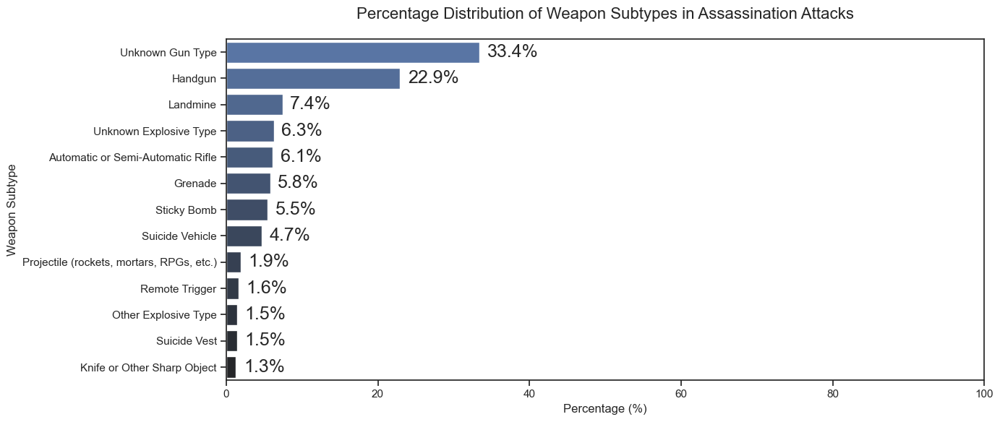

In [254]:
# Set the Seaborn theme
sns.set_theme(style='ticks')
palette = 'dark:b_r'

# Filter for assassination attacks
assassination_attacks = df[df['attack_type'] == 'Assassination']

# Count weapon subtypes used in assassination attacks
weapon_counts = assassination_attacks['weapon_subtype'].value_counts().head(13)

# Calculate percentages
weapon_percentages = (weapon_counts / weapon_counts.sum()) * 100

# Visualization - Horizontal Bar Chart
plt.figure(figsize=(14, 6))
sns.barplot(y=weapon_percentages.index, x=weapon_percentages.values, palette=palette)

# Set titles and labels
plt.title('Percentage Distribution of Weapon Subtypes in Assassination Attacks', pad=20, fontsize=16)
plt.ylabel('Weapon Subtype')
plt.xlabel('Percentage (%)')
plt.xlim(0, 100)  # Set x-axis limits to [0, 100]

# Show the percentage values on the right of the bars
for index, value in enumerate(weapon_percentages):
    plt.text(value + 1, index, f"{value:.1f}%", ha='left', va='center', fontsize=18)

plt.tight_layout()  # Adjust the layout
plt.show()

### **7. Casualty Analysis**

- ### **What are the total casualties by region and city?** 

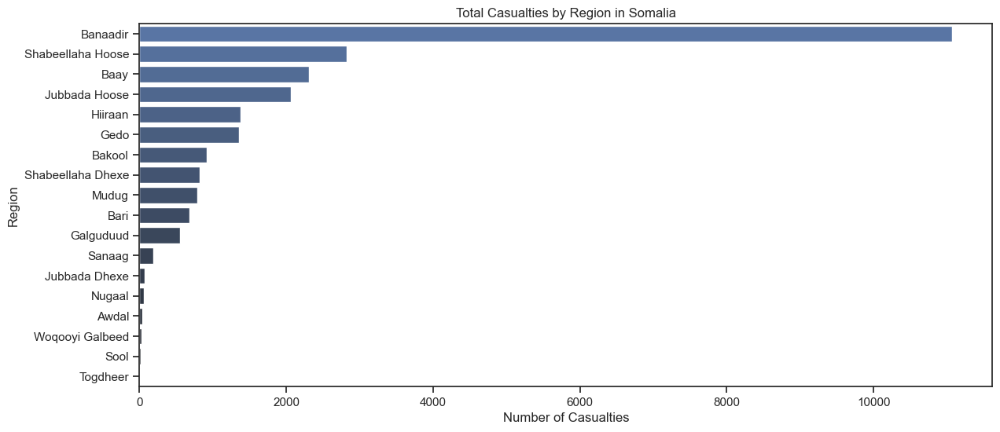

In [255]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = 'dark:b_r'
df_reg = df[df['region'] != 'Unknown']
# Group by region and calculate the total casualties for each region
region_casualties = df_reg.groupby('region')['total_casualties'].sum().reset_index().sort_values(by='total_casualties', ascending=False)

# Visualization
plt.figure(figsize=(14, 6))

# Create the bar plot for total casualties by region
sns.barplot(x='total_casualties', y='region', data=region_casualties, palette=palette)

# Set plot title and labels
plt.title('Total Casualties by Region in Somalia')
plt.xlabel('Number of Casualties')
plt.ylabel('Region')
plt.xticks(rotation=0)

# Show the plot
plt.show()

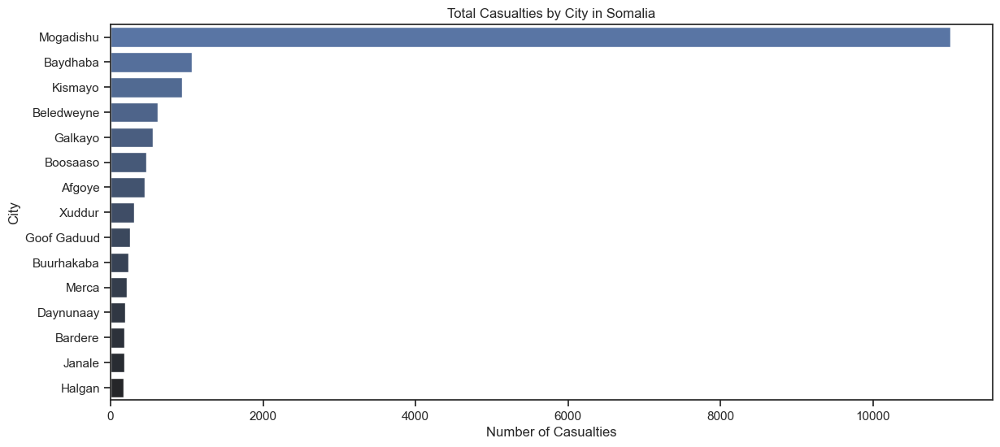

In [256]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = 'dark:b_r'
df_cit = df[df['city']!= 'Unknown']
# Group by region and calculate the total casualties for each region
city_casualties = df_cit.groupby('city')['total_casualties'].sum().reset_index().sort_values(by='total_casualties', ascending=False)
city_casualties = city_casualties.head(15)
# Visualization
plt.figure(figsize=(14, 6))

# Create the bar plot for total casualties by region
sns.barplot(x='total_casualties', y='city', data=city_casualties, palette=palette)

# Set plot title and labels
plt.title('Total Casualties by City in Somalia')
plt.xlabel('Number of Casualties')
plt.ylabel('City')
plt.xticks(rotation=0)

# Show the plot
plt.show()

- ### **What percentage of attacks result in casualties?**  

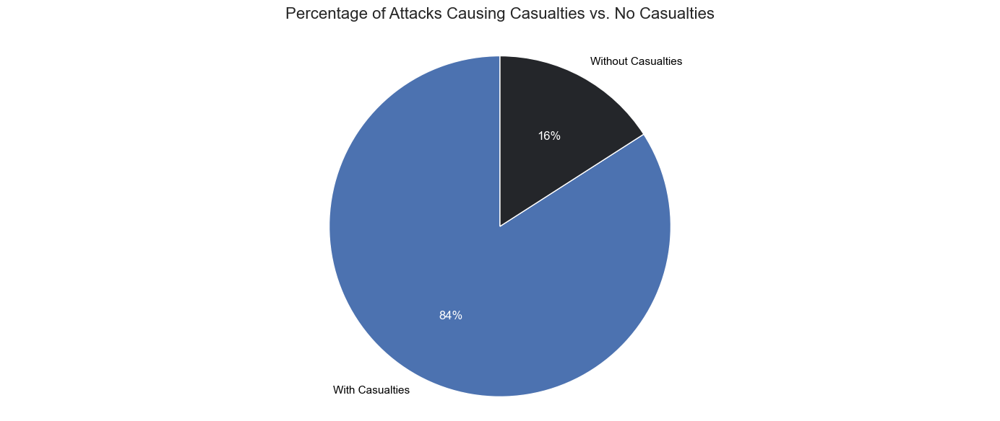

In [286]:
# Set the Seaborn theme
sns.set_theme(style='ticks')
palette = 'dark:b_r'

# Calculate the total number of attacks
total_attacks = len(df)

# Count attacks that resulted in casualties
attacks_with_casualties = len(df[df['total_casualties'] > 0])

# Calculate the percentage of attacks that resulted in casualties and those that did not
casualty_percentage = (attacks_with_casualties / total_attacks) * 100
no_casualty_percentage = 100 - casualty_percentage

# Create data for the pie chart
casualty_data = [casualty_percentage, no_casualty_percentage]
labels = ['With Casualties', 'Without Casualties']

# Visualization - Pie chart
plt.figure(figsize=(14, 6))
wedges, texts, autotexts = plt.pie(
    casualty_data, 
    labels=labels, 
    autopct='%1.0f%%', 
    startangle=90, 
    colors=sns.color_palette(palette, len(casualty_data))
)

# Set text properties
for text in texts:
    text.set_color('black')  # Set labels to black

for autotext in autotexts:
    autotext.set_color('white')  # Set percentage text to white

# Title and aspect ratio
plt.title('Percentage of Attacks Causing Casualties vs. No Casualties', pad=20, fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()  # Adjust layout
plt.show()

- ### **How do casualty rates vary by attack type?**  

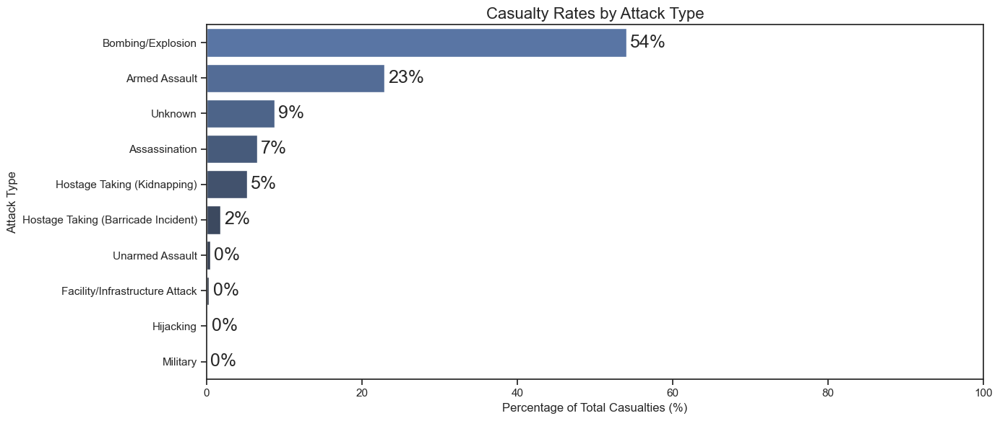

In [271]:
# Set the Seaborn theme
sns.set_theme(style='ticks')
palette = 'dark:b_r'

# Calculate total casualties by attack type
casualties_by_attack_type = df.groupby('attack_type')['total_casualties'].sum().sort_values(ascending=False)

# Calculate the percentage of total casualties by attack type
casualty_percentage = (casualties_by_attack_type / casualties_by_attack_type.sum()) * 100

# Visualization - Horizontal Bar Chart
plt.figure(figsize=(14, 6))
sns.barplot(x=casualty_percentage.values, y=casualty_percentage.index, palette=palette)

# Set titles and labels
plt.title('Casualty Rates by Attack Type', fontsize=16)
plt.xlabel('Percentage of Total Casualties (%)')
plt.ylabel('Attack Type')

# Display percentage values on the bars
for index, value in enumerate(casualty_percentage.values):
    plt.text(value + 0.5, index, f'{value:.0f}%', va='center', fontsize=18)

plt.xlim(0, 100)  # Set x-axis limit to [0, 100]
plt.tight_layout()  # Adjust the layout
plt.show()

- ### **Are there any Nociable Terrorism attacks with high casualties?**  

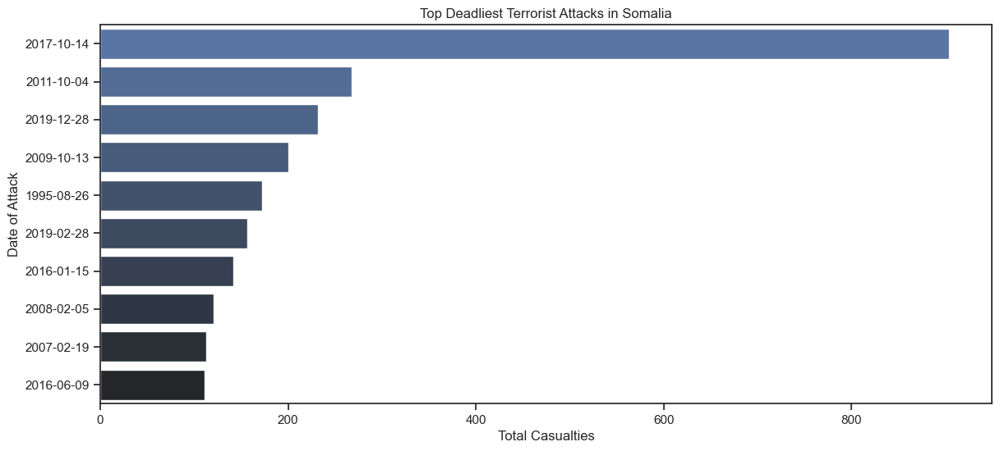

In [259]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Find the deadliest attacks by sorting the total casualties
deadliest_attacks = df[['eventid', 'date', 
                        'city', 'region', 'total_casualties']].sort_values(by='total_casualties', 
                                                                           ascending=False).head(10)
# Visualization: Bar chart of the deadliest attacks
plt.figure(figsize=(14, 6))
sns.barplot(data=deadliest_attacks, x='total_casualties', y='date', palette=palette)
plt.title('Top Deadliest Terrorist Attacks in Somalia')
plt.xlabel('Total Casualties')
plt.ylabel('Date of Attack')
plt.show()

- ### **Terrorism attacks with highest killed people**

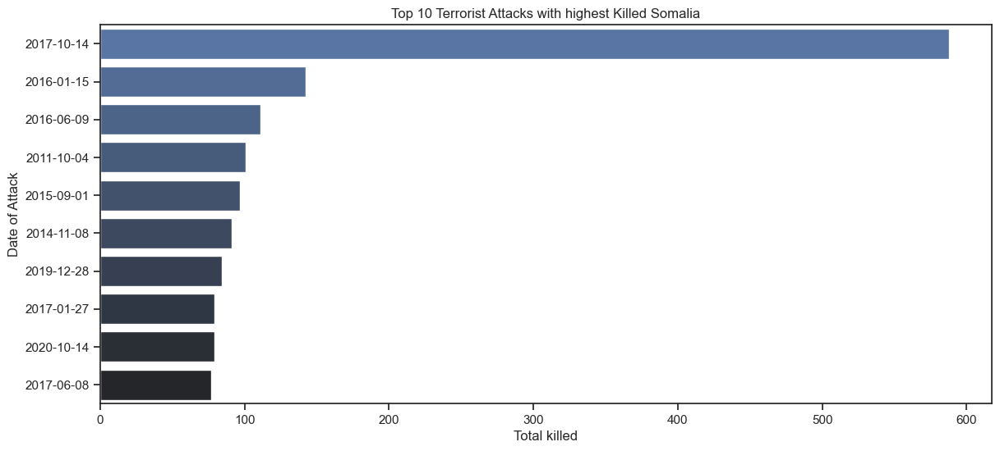

In [260]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Find the deadliest attacks by sorting the total casualties
deadliest_attacks = df[['eventid', 'date', 
                        'city', 'region', 'killed']].sort_values(by='killed', 
                                                                           ascending=False).head(10)
# Visualization: Bar chart of the deadliest attacks
plt.figure(figsize=(14, 6))
sns.barplot(data=deadliest_attacks, x='killed', y='date', palette=palette)
plt.title('Top 10 Terrorist Attacks with highest Killed Somalia')
plt.xlabel('Total killed')
plt.ylabel('Date of Attack')
plt.show()

- ### **Terrorism attacks with highest wounded people**

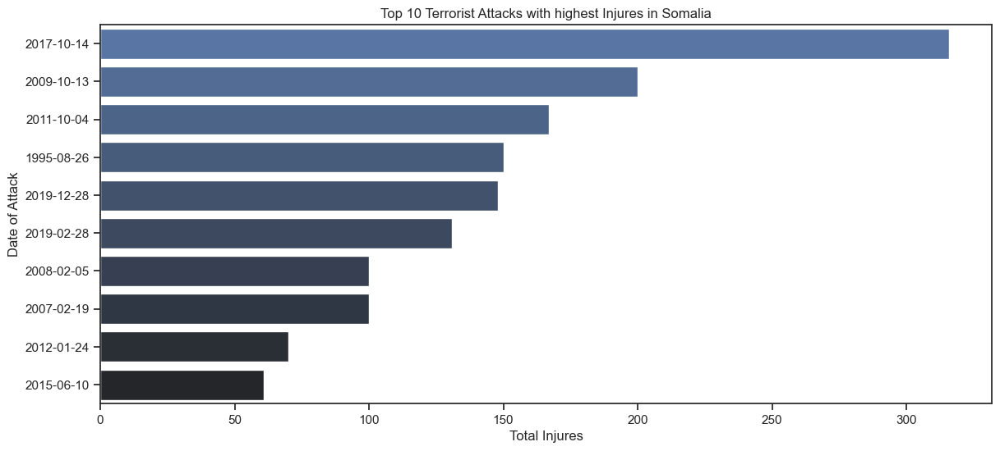

In [261]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Find the deadliest attacks by sorting the total casualties
deadliest_attacks = df[['eventid', 'date', 
                        'city', 'region', 'wounded']].sort_values(by='wounded', 
                                                                           ascending=False).head(10)
# Visualization: Bar chart of the deadliest attacks
plt.figure(figsize=(14, 6))
sns.barplot(data=deadliest_attacks, x='wounded', y='date', palette=palette)
plt.title('Top 10 Terrorist Attacks with highest Injures in Somalia')
plt.xlabel('Total Injures')
plt.ylabel('Date of Attack')
plt.show()

- ### **Top 5 highest killed by year in Somalia**

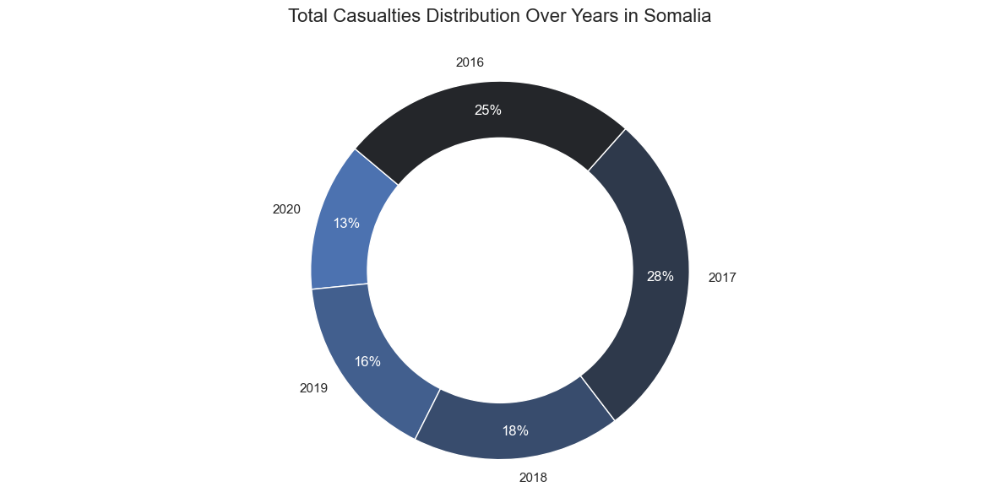

In [262]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = 'dark:b_r'

# Prepare the Data
affected = df.groupby(['year'])['total_casualties'].sum().sort_index(ascending=False).reset_index().head()

# Calculate percentages
total_casualties = affected['total_casualties'].sum()
affected['percentage'] = (affected['total_casualties'] / total_casualties) * 100

# Create the donut chart
plt.figure(figsize=(12, 6))
colors = sns.color_palette(palette, n_colors=len(affected))

# Draw the pie chart
wedges, texts, autotexts = plt.pie(affected['total_casualties'], 
                                    labels=affected['year'], 
                                    autopct='',  # Remove default autopct to customize later
                                    startangle=140, 
                                    colors=colors, 
                                    pctdistance=0.85)

# Draw a circle at the center of pie to make it look like a donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add percentages manually for better control over text appearance
for i, a in enumerate(autotexts):
    percentage = f'{affected["percentage"].iloc[i]:.0f}%'
    a.set_text(percentage)  # Set the percentage text
    a.set_color('white')     # Change the text color to white
    a.set_fontsize(12)       # Optionally, adjust font size for better visibility

# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis('equal')  
plt.title('Total Casualties Distribution Over Years in Somalia', fontsize=16, pad=35)
plt.tight_layout()  # Adjust layout to make room for the donut shape
plt.show()

- ### **Percentage of casualties in by suicide and non suicide attacks**

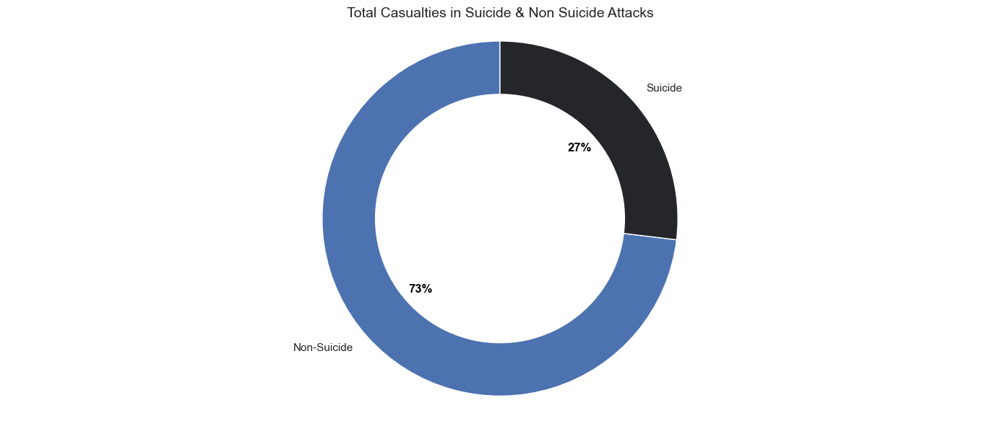

In [263]:
# Set the Seaborn theme and palette
sns.set_theme(style='ticks')
palette = 'dark:b_r'

# Group by suicide flag and sum total casualties
suicide_casualties = df.groupby('suicide')['total_casualties'].sum().reset_index()
# Map boolean to labels for better readability
suicide_casualties['suicide'] = suicide_casualties['suicide'].map({0: 'Non-Suicide', 1: 'Suicide'})
# Prepare data for the donut chart
sizes = suicide_casualties['total_casualties']
labels = suicide_casualties['suicide']

# Set up the figure
plt.figure(figsize=(14, 6))
# Create a pie chart
wedges, texts, autotexts = plt.pie(sizes, labels=labels, 
                                   autopct='%1.0f%%', startangle=90, 
                                   colors=sns.color_palette(palette, len(labels)))
# Draw a white circle at the center to create a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
# Equal aspect ratio ensures that pie chart is a circle
plt.axis('equal')  
plt.title("Total Casualties in Suicide & Non Suicide Attacks", fontsize=14)
plt.setp(autotexts, size=12, weight="bold", color="black")
# Show the plot
plt.tight_layout()
plt.show()

- ### **Most Targeted hotels in Mogadishu**

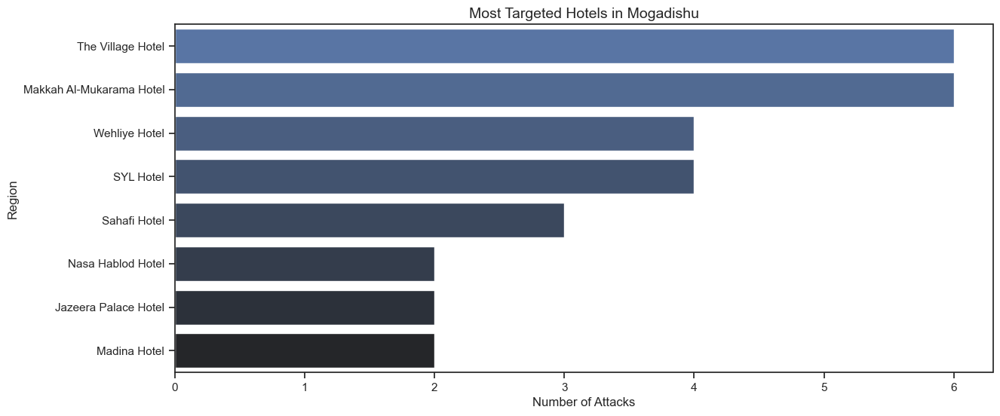

In [264]:
sns.set_theme(style='ticks')
palette = 'dark:b_r'
# Filter the DataFrame for attacks targeting hotels
hotel_attacks = df[df['target_subtype'] == 'Hotel/Resort']

# Count attacks by region (state or city)
vulnerable_regions = hotel_attacks['target'].value_counts().head(8)  # Change 'state' to 'city' if needed

# Visualization: Bar chart of vulnerable regions
plt.figure(figsize=(14, 6))
sns.barplot(x=vulnerable_regions.values, y=vulnerable_regions.index, palette=palette)
plt.title('Most Targeted Hotels in Mogadishu', fontsize=14)
plt.xlabel('Number of Attacks')
plt.ylabel('Region')
plt.show()

### Insight on Terrorism in Somalia


#### Introduction
Terrorism in Somalia remains a significant challenge, with various attack methods contributing to widespread casualties. This analysis delves into the characteristics of terrorist attacks in Somalia, focusing on the types of attacks, weapon usage, regional impacts, and trends over time. The insights gathered provide a comprehensive understanding of the current security landscape, guiding future interventions to improve safety and stability.


#### Key Findings

1. **Casualty Distribution**:
   - A significant **73%** of total casualties are attributed to **non-suicide attacks**, highlighting that while suicide attacks are notable, they do not represent the majority of fatalities.
   - **Suicide bombings** account for **27%** of casualties, suggesting that while impactful, they are less frequent compared to other methods.

2. **Attack Types and Weapon Correlations**:
   - The analysis reveals a **significant correlation** between certain attack types and specific weapon types. 
   - **Armed Assaults** primarily use **firearms**, while **Bombing/Explosion** incidents are predominantly linked to **explosives**.
   - **Assassinations** often involve **firearms**, with a notable reliance on **Unknown Gun Type** (33.4% of incidents), reflecting the challenges faced in tracking firearms.
   - The **Hostage Taking** incidents show a diverse range of weapon usage, indicating the complexity of tactical approaches in these scenarios.

3. **Tactics of Suicide Attacks**:
   - **Suicide vehicles** are the preferred method for executing suicide attacks, constituting **74%** of such incidents, while **suicide vests** account for **26%**. This preference for vehicles highlights the strategic choice to maximize impact and fatalities.

4. **Regional Concentrations**:
   - **Banaadir**, **Shabeellaha Hoose**, **Bay**, and **Jubbada Hoose** are the regions with the highest casualty figures, indicating focal points for violence.
   - In urban contexts, **Mogadishu**, **Baydhaba**, and **Kismayo** experience the highest number of casualties, suggesting targeted interventions are necessary in these cities.
   - Other regions, such as **Shabeellaha Dhexe**, **Gedo**, **Hiraan**, **Mudug**, and **Bari**, report significantly lower casualties, potentially reflecting different levels of stability, governance, and security presence.

5. **Temporal Trends**:
   - The deadliest attack occurred on **October 14, 2017**, marking a critical moment in Somalia's struggle against terrorism, with significant casualties. 
   - A declining trend in casualties in more recent years (2019 and 2020) may indicate improved security measures or shifts in terrorist tactics, suggesting a need for ongoing evaluation of the effectiveness of counter-terrorism strategies.

6. **Tactics and Locations**:
   - The **Village Hotel** and **Makkah Al-Mukarama Hotel** are frequently targeted, each experiencing **6 attacks**, underscoring their status as high-value targets. The concentration of attacks in urban hotels highlights the vulnerability of public spaces.
   - A majority of attacks (84%) resulted in casualties, indicating that many attacks are aimed at instilling fear or achieving tactical objectives, with only 16% of attacks occurring without casualties.

7. **Types of Casualties**:
   - **Bombing/Explosion** attacks are responsible for **54%** of total casualties, making them the most lethal type. This underscores the ongoing threat posed by explosives in the region.
   - **Armed Assaults** account for **23%** of casualties, indicating that while serious, they tend to result in fewer casualties per event compared to bombings.

8. **Patterns of Weapon Usage**:
   - The **Unknown Gun Type** is the most frequently used weapon subtype in assassination attacks, reflecting the challenges in identifying and tracking the firearms involved in these incidents.
   - The presence of **Handguns**, **Landmines**, and **Unknown Explosive Type** highlights a reliance on both firearms and explosives for carrying out assassinations.

9. **Yearly Casualty Trends**:
    - **2017** stands out as the year with the highest proportion of total casualties, accounting for **29%** of all casualties recorded in the five-year span, followed closely by **2016** (25%). 
    - The data indicates fluctuations in casualty figures, suggesting changes in the security landscape in Somalia and reflecting specific incidents or escalated conflict during those years.

#### Recommendations

1. **Broader Counter-Terrorism Strategies**:
   - Given the predominance of non-suicide attacks, security forces should enhance their training and operational readiness to address a variety of terrorist tactics, focusing on bombings and armed assaults.

2. **Intelligence Gathering**:
   - Increase efforts in intelligence collection to better understand the dynamics of attacks and the weapons used, particularly firearms and explosives, which pose the most significant threats.

3. **Targeted Security Measures**:
   - Implement enhanced security protocols in high-casualty regions and cities. This could involve increased military presence, community engagement initiatives, and public awareness campaigns to reduce vulnerability.

4. **Protection of High-Value Targets**:
   - Strengthen security around hotels and public spaces frequently targeted by terrorists, including implementing strict entry controls and surveillance measures.

5. **Focus on Journalists and Media Safety**:
   - Advocate for laws and measures to protect journalists and media personnel, addressing the ongoing violence against those working in the media sector.

6. **Monitoring and Data Analysis**:
   - Establish a continuous monitoring system for terrorist activities, ensuring timely data collection and analysis to adapt strategies effectively and respond to evolving threats.

#### Conclusion
The landscape of terrorism in Somalia is characterized by a complex interplay of attack methods, casualty patterns, and regional dynamics. The insights derived from this analysis indicate a pressing need for comprehensive and targeted security measures to address the multifaceted nature of terrorism. By implementing the recommendations outlined, Somalia can work towards enhancing security and stability, ultimately fostering a safer environment for its citizens. Continuous evaluation and adaptation to the changing security landscape will be crucial in the fight against terrorism, ensuring that efforts are effectively aligned with the realities on the ground.